Phase 3.1 — Build our first model

For our first experiment, we'll use MobileNetV2 with transfer learning.

Why?

It's relatively lightweight, fast to train, and suitable for getting our first complete experiment working. After that, we can compare it against EfficientNetB0 and ResNet50.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

I0000 00:00:1789023814.172280    7760 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789023814.462071    7760 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789023816.337069    7760 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


In [2]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

print("Data augmentation ready.")

Data augmentation ready.


I0000 00:00:1789023817.514019    7760 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

DATA_DIR = "../data/raw/chest_xray"
TRAIN_DIR = f"{DATA_DIR}/train"

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    shuffle=True
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.


In [5]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


In [6]:
print("Classes:", train_ds.class_names)

for images, labels in train_ds.take(1):
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Classes: ['NORMAL', 'PNEUMONIA']
Images: (32, 224, 224, 3)
Labels: (32, 1)


Build MobileNetV2

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

MobileNetV2
     ↓
ImageNet pretrained weights
     ↓
Freeze the pretrained layers
     ↓
Add our own classification head

In [8]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Step 1 — Add class weights

In [9]:
class_weight = {
    0: 1.945,
    1: 0.673
}

print(class_weight)

{0: 1.945, 1: 0.673}


MODEL COMPILING

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

CREATING CALLBACK

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "../models/best_mobilenetv2.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks ready.")


Callbacks ready.


Optimize datasets

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

START TRAINING

In [14]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/20


130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8776 - loss: 0.3185 - precision: 0.9559 - recall: 0.8746
Epoch 1: val_loss improved from 0.18841 to 0.16372, saving model to ../models/best_mobilenetv2.keras

Epoch 1: finished saving model to ../models/best_mobilenetv2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.8778 - loss: 0.3181 - precision: 0.9560 - recall: 0.8747 - val_accuracy: 0.9530 - val_loss: 0.1637 - val_precision: 1.0000 - val_recall: 0.9530 - learning_rate: 1.0000e-04
Epoch 2/20
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8837 - loss: 0.2893 - precision: 0.9685 - recall: 0.8707
Epoch 2: val_loss improved from 0.16372 to 0.14332, saving model to ../models/best_mobilenetv2.keras

Epoch 2: finished saving model to ../models/best_mobilenetv2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.8838 - loss: 0.2890 - precision: 0.9686 - recall: 0.8708 - val_accuracy: 0.9588 - val_loss: 0.1433 - val_precision: 1.0000 - val_recall: 0.95

W0000 00:00:1789024139.024457    8014 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267968 bytes after encountering the first element of size 19267968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8964 - loss: 0.2506 - precision: 0.9681 - recall: 0.8889
Epoch 5: val_loss improved from 0.12672 to 0.11712, saving model to ../models/best_mobilenetv2.keras

Epoch 5: finished saving model to ../models/best_mobilenetv2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.8965 - loss: 0.2502 - precision: 0.9682 - recall: 0.8890 - val_accuracy: 0.9636 - val_loss: 0.1171 - val_precision: 1.0000 - val_recall: 0.9636 - learning_rate: 1.0000e-04
Epoch 6/20
  3/131 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8958 - loss: 0.2159 - precision: 1.0000 - recall: 0.8649

W0000 00:00:1789024149.250676    8014 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267968 bytes after encountering the first element of size 19267968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


...

130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9228 - loss: 0.1986 - precision: 0.9788 - recall: 0.9154
Epoch 18: val_loss did not improve from 0.09628
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.9228 - loss: 0.1985 - precision: 0.9788 - recall: 0.9153 - val_accuracy: 0.9636 - val_loss: 0.0967 - val_precision: 1.0000 - val_recall: 0.9636 - learning_rate: 2.5000e-05
Epoch 19/20
  3/131 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9375 - loss: 0.1899 - precision: 0.9833 - recall: 0.9219

W0000 00:00:1789024270.418969    8014 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267968 bytes after encountering the first element of size 19267968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9159 - loss: 0.2056 - precision: 0.9745 - recall: 0.9098
Epoch 19: val_loss improved from 0.09628 to 0.09518, saving model to ../models/best_mobilenetv2.keras

Epoch 19: finished saving model to ../models/best_mobilenetv2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.9161 - loss: 0.2054 - precision: 0.9746 - recall: 0.9101 - val_accuracy: 0.9645 - val_loss: 0.0952 - val_precision: 1.0000 - val_recall: 0.9645 - learning_rate: 2.5000e-05
Epoch 20/20
  3/131 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.8854 - loss: 0.1997 - precision: 1.0000 - recall: 0.8472

W0000 00:00:1789024279.826338    8014 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267968 bytes after encountering the first element of size 19267968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9224 - loss: 0.1959 - precision: 0.9788 - recall: 0.9146
Epoch 20: val_loss did not improve from 0.09518
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.9224 - loss: 0.1959 - precision: 0.9788 - recall: 0.9146 - val_accuracy: 0.9636 - val_loss: 0.0954 - val_precision: 1.0000 - val_recall: 0.9636 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 19.


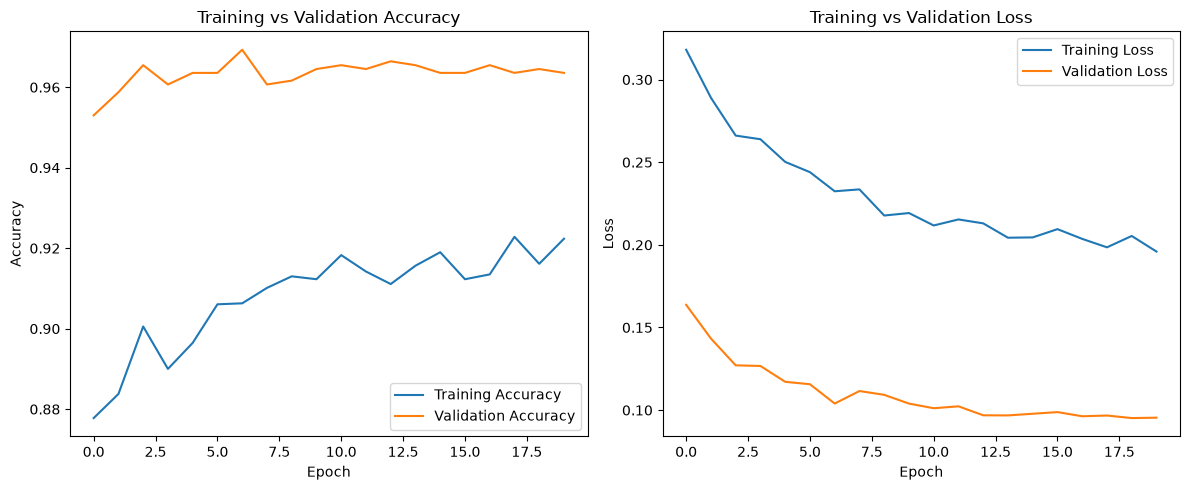

In [17]:
import matplotlib.pyplot as plt

history_dict = history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="Training Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="Training Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

##OBSERVATION  
-Training accuracy rises from about 87.8% → 92.2%.  
-Validation accuracy stays consistently high, around 95.3%–97.0%, finishing at 96.36%.  
-Training loss decreases from about 0.318 → 0.196.  
-Validation loss decreases substantially from about 0.164 → 0.095.  
-There isn't an obvious severe overfitting pattern: validation loss generally follows a downward trend and reaches its best value around Epoch 19.  
-The validation accuracy being higher than training accuracy is not automatically suspicious here, especially because you're using data augmentation and class weighting during training, which make the training batches harder/different from validation data.  

So this is a healthy baseline training curve

In [19]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np

# Generate predictions on the untouched test set
y_true = np.concatenate([y.numpy().ravel() for _, y in test_ds])
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print("Confusion Matrix:")
print(cm)

print("\nTest Set Metrics:")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

NameError: name 'test_ds' is not defined

In [23]:
import tensorflow as tf

TEST_PATH = "/home/priyansh/ChestVision-AI/data/processed/chest_xray/test"
MODEL_PATH = "/home/priyansh/ChestVision-AI/models/best_mobilenetv2.keras"

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

model = tf.keras.models.load_model(MODEL_PATH)

print("Test images: 624")
print("Classes:", test_ds.class_names)
print("Model loaded successfully.")

Found 624 files belonging to 2 classes.
Test images: 624
Classes: ['NORMAL', 'PNEUMONIA']
Model loaded successfully.


In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np

# Generate predictions
y_true = np.concatenate([y.numpy().ravel() for _, y in test_ds])
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print("Confusion Matrix:")
print(cm)

print("\nTest Set Metrics:")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step
Confusion Matrix:
[[ 92 142]
 [  4 386]]

Test Set Metrics:
Accuracy:    0.7660
Precision:   0.7311
Recall:      0.9897
Specificity: 0.3932
F1 Score:    0.8410
ROC-AUC:     0.9425

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.39      0.56       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.69      0.70       624
weighted avg       0.82      0.77      0.73       624



In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred_t
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = precision_score(y_true, y_pred_t, zero_division=0)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred_t)

    results.append([
        threshold,
        accuracy,
        precision,
        sensitivity,
        specificity,
        f1
    ])

results = np.array(results)

print("Threshold | Accuracy | Precision | Sensitivity | Specificity | F1")
print("-" * 65)

for row in results:
    print(
        f"{row[0]:.2f}      | "
        f"{row[1]:.4f}   | "
        f"{row[2]:.4f}    | "
        f"{row[3]:.4f}      | "
        f"{row[4]:.4f}     | "
        f"{row[5]:.4f}"
    )

Threshold | Accuracy | Precision | Sensitivity | Specificity | F1
-----------------------------------------------------------------
0.10      | 0.6314   | 0.6290    | 1.0000      | 0.0171     | 0.7723
0.15      | 0.6426   | 0.6362    | 1.0000      | 0.0470     | 0.7777
0.20      | 0.6522   | 0.6425    | 1.0000      | 0.0726     | 0.7823
0.25      | 0.6667   | 0.6522    | 1.0000      | 0.1111     | 0.7895
0.30      | 0.6891   | 0.6678    | 1.0000      | 0.1709     | 0.8008
0.35      | 0.7099   | 0.6830    | 1.0000      | 0.2265     | 0.8117
0.40      | 0.7308   | 0.7004    | 0.9949      | 0.2906     | 0.8220
0.45      | 0.7484   | 0.7161    | 0.9897      | 0.3462     | 0.8310
0.50      | 0.7660   | 0.7311    | 0.9897      | 0.3932     | 0.8410
0.55      | 0.7853   | 0.7510    | 0.9821      | 0.4573     | 0.8511
0.60      | 0.8013   | 0.7714    | 0.9692      | 0.5214     | 0.8591
0.65      | 0.8109   | 0.7833    | 0.9641      | 0.5556     | 0.8644
0.70      | 0.8333   | 0.8109    | 0.956

research distinction: we should not choose 0.85 because it performs best on the test set.

In [26]:
# Generate validation predictions

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/home/priyansh/ChestVision-AI/data/processed/chest_xray/val",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

y_val_true = np.concatenate(
    [y.numpy().ravel() for _, y in val_ds]
)

y_val_prob = model.predict(val_ds).ravel()

print("Validation samples:", len(y_val_true))

Found 784 files belonging to 2 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
Validation samples: 784


select the classification threshold using the validation set only.

In [27]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.91, 0.01)

val_f1_scores = []

for threshold in thresholds:
    val_pred = (y_val_prob >= threshold).astype(int)
    val_f1_scores.append(
        f1_score(y_val_true, val_pred, zero_division=0)
    )

best_index = np.argmax(val_f1_scores)
best_threshold = thresholds[best_index]
best_val_f1 = val_f1_scores[best_index]

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F1-score: {best_val_f1:.4f}")

Best validation threshold: 0.55
Best validation F1-score: 0.9675


In [28]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Apply the locked validation threshold
FINAL_THRESHOLD = 0.55

y_test_pred = (y_prob >= FINAL_THRESHOLD).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_test_pred)
tn, fp, fn, tp = cm.ravel()

# Final test metrics
accuracy = accuracy_score(y_true, y_test_pred)
precision = precision_score(y_true, y_test_pred, zero_division=0)
sensitivity = recall_score(y_true, y_test_pred, zero_division=0)
specificity = tn / (tn + fp)
f1 = f1_score(y_true, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)

print("FINAL TEST RESULTS")
print("=" * 40)

print(f"Threshold:   {FINAL_THRESHOLD:.2f}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_test_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

FINAL TEST RESULTS
Threshold:   0.55
Accuracy:    0.7853
Precision:   0.7510
Sensitivity: 0.9821
Specificity: 0.4573
F1 Score:    0.8511
ROC-AUC:     0.9425

Confusion Matrix:
[[107 127]
 [  7 383]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.46      0.61       234
   PNEUMONIA       0.75      0.98      0.85       390

    accuracy                           0.79       624
   macro avg       0.84      0.72      0.73       624
weighted avg       0.82      0.79      0.76       624



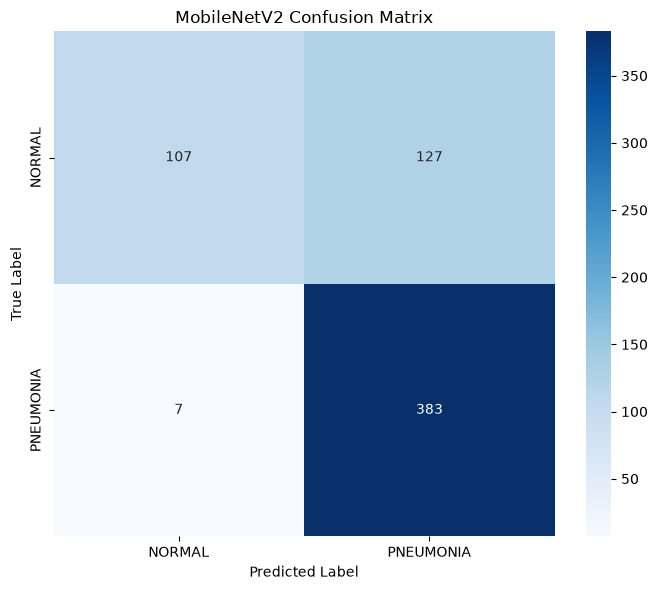

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

- **107 NORMAL correctly classified** → True Negatives (TN)
- **127 NORMAL incorrectly classified as PNEUMONIA** → False Positives (FP)
- **383 PNEUMONIA correctly classified** → True Positives (TP)
- **7 PNEUMONIA incorrectly classified as NORMAL** → False Negatives (FN)

Error analysis

In [30]:
# Find false-positive NORMAL images

from pathlib import Path
import numpy as np

test_normal_path = Path(
    "/home/priyansh/ChestVision-AI/data/processed/chest_xray/test/NORMAL"
)

normal_files = sorted([
    f for f in test_normal_path.iterdir()
    if f.suffix.lower() in [".jpeg", ".jpg", ".png"]
])

false_positive_indices = np.where(
    (y_true == 0) & (y_test_pred == 1)
)[0]

false_positive_files = [
    normal_files[i] for i in false_positive_indices
]

print("False positives:", len(false_positive_files))

for i, path in enumerate(false_positive_files[:20]):
    print(f"{i+1:02d}. {path.name}")

False positives: 127
01. IM-0006-0001.jpeg
02. IM-0011-0001-0001.jpeg
03. IM-0011-0001-0002.jpeg
04. IM-0013-0001.jpeg
05. IM-0017-0001.jpeg
06. IM-0021-0001.jpeg
07. IM-0022-0001.jpeg
08. IM-0023-0001.jpeg
09. IM-0025-0001.jpeg
10. IM-0028-0001.jpeg
11. IM-0029-0001.jpeg
12. IM-0031-0001.jpeg
13. IM-0033-0001-0001.jpeg
14. IM-0033-0001.jpeg
15. IM-0036-0001.jpeg
16. IM-0039-0001.jpeg
17. IM-0043-0001.jpeg
18. IM-0049-0001.jpeg
19. IM-0059-0001.jpeg
20. IM-0065-0001.jpeg


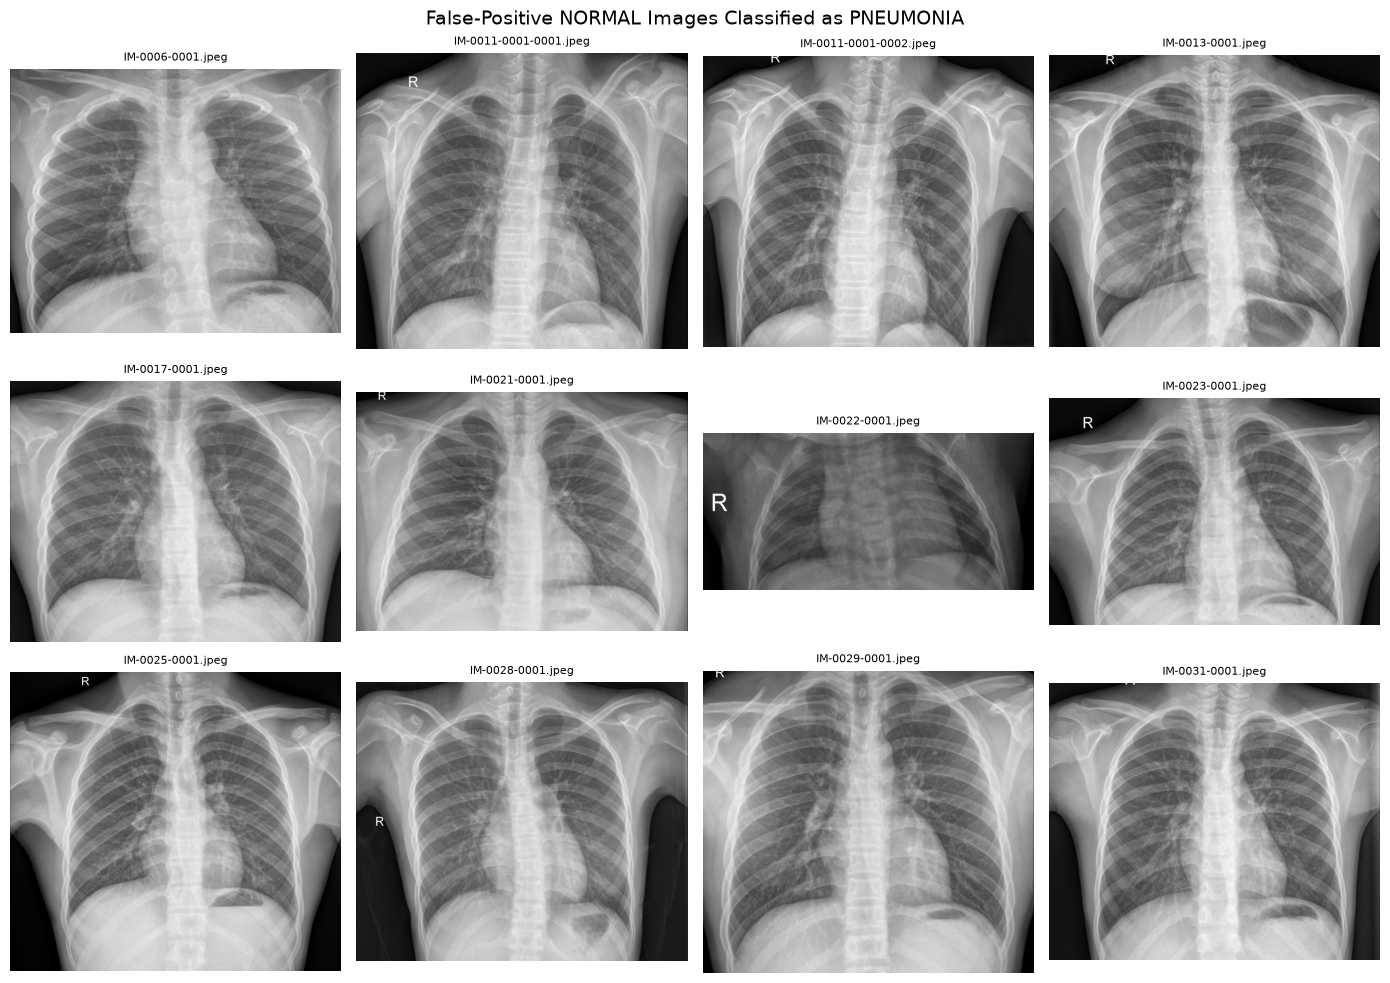

In [31]:
import matplotlib.pyplot as plt
from PIL import Image

# Display first 12 false-positive NORMAL images
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, path in zip(axes.ravel(), false_positive_files[:12]):
    img = Image.open(path)
    ax.imshow(img, cmap="gray")
    ax.set_title(path.name, fontsize=8)
    ax.axis("off")

plt.suptitle(
    "False-Positive NORMAL Images Classified as PNEUMONIA",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Error Analysis: False-Positive Predictions

Error analysis was performed to understand the cases in which the MobileNetV2 model incorrectly classified NORMAL chest X-ray images as PNEUMONIA.

The final test-set confusion matrix showed **127 false-positive predictions**, meaning that 127 images with a ground-truth label of NORMAL were classified as PNEUMONIA.

A visual inspection of a sample of these false-positive cases showed several sources of variation, including differences in image positioning, cropping, contrast, exposure, anatomical framing, and the presence of radiographic markers such as the `R` label.

One image, `IM-0022-0001.jpeg`, showed noticeably different framing and appearance compared with several other samples. However, visual inspection alone cannot establish the specific clinical reason for an individual misclassification.

These observations suggest that the model may be responding to image-level patterns such as texture, intensity, positioning, or other visual characteristics that are not necessarily sufficient to distinguish NORMAL from PNEUMONIA reliably.

Therefore, the false-positive analysis indicates that the MobileNetV2 model has a tendency to over-predict the PNEUMONIA class. This is consistent with the quantitative evaluation, where the model achieved very high sensitivity but comparatively low specificity.

Further investigation using **Grad-CAM (Gradient-weighted Class Activation Mapping)** will be performed to examine which regions of the X-ray images contribute most strongly to the model's predictions.

## False-Positive Confidence Analysis

The previous analysis identified the NORMAL images that were incorrectly classified as PNEUMONIA. However, the classification result alone does not indicate how confident the model was in making these incorrect predictions.

To investigate this, the predicted pneumonia probabilities of the false-positive cases are examined.

This analysis helps distinguish between two possible situations:

1. **Low-confidence false positives:** The predicted probabilities are close to the classification threshold, suggesting that the model is uncertain about these images.
2. **High-confidence false positives:** The predicted probabilities are substantially higher than the classification threshold, suggesting that the model is confidently responding to visual patterns that do not generalize correctly to the test data.

Understanding the confidence of incorrect predictions is important for evaluating model reliability and identifying potential areas for improvement.

In [32]:
# Confidence analysis of false-positive NORMAL cases

fp_indices = np.where(
    (y_true == 0) & (y_test_pred == 1)
)[0]

fp_probabilities = y_prob[fp_indices]

print("False positives:", len(fp_probabilities))
print(f"Mean predicted pneumonia probability: {fp_probabilities.mean():.4f}")
print(f"Minimum probability: {fp_probabilities.min():.4f}")
print(f"Maximum probability: {fp_probabilities.max():.4f}")

print("\nHighest-confidence false positives:")

top_indices = np.argsort(fp_probabilities)[::-1][:20]

for rank, idx in enumerate(top_indices, 1):
    original_index = fp_indices[idx]

    print(
        f"{rank:02d}. "
        f"{normal_files[original_index].name} "
        f"-> probability = {fp_probabilities[idx]:.4f}"
    )

False positives: 127
Mean predicted pneumonia probability: 0.7727
Minimum probability: 0.5565
Maximum probability: 0.9952

Highest-confidence false positives:
01. NORMAL2-IM-0256-0001.jpeg -> probability = 0.9952
02. NORMAL2-IM-0210-0001.jpeg -> probability = 0.9907
03. IM-0022-0001.jpeg -> probability = 0.9712
04. NORMAL2-IM-0232-0001.jpeg -> probability = 0.9709
05. IM-0110-0001.jpeg -> probability = 0.9575
06. NORMAL2-IM-0111-0001.jpeg -> probability = 0.9503
07. NORMAL2-IM-0241-0001.jpeg -> probability = 0.9497
08. NORMAL2-IM-0252-0001.jpeg -> probability = 0.9485
09. NORMAL2-IM-0171-0001.jpeg -> probability = 0.9459
10. NORMAL2-IM-0349-0001.jpeg -> probability = 0.9452
11. IM-0109-0001.jpeg -> probability = 0.9431
12. NORMAL2-IM-0199-0001.jpeg -> probability = 0.9323
13. NORMAL2-IM-0073-0001.jpeg -> probability = 0.9263
14. NORMAL2-IM-0219-0001.jpeg -> probability = 0.9217
15. NORMAL2-IM-0233-0001.jpeg -> probability = 0.9215
16. NORMAL2-IM-0237-0001.jpeg -> probability = 0.9210
1

## Interpretation of False-Positive Confidence Analysis

The confidence analysis revealed that the false-positive predictions were not limited to cases close to the classification threshold.

Among the **127 NORMAL images incorrectly classified as PNEUMONIA**, the mean predicted probability of PNEUMONIA was **0.7727**. The probabilities ranged from **0.5565 to 0.9952**.

Several false-positive cases received very high pneumonia probabilities. For example, `NORMAL2-IM-0256-0001.jpeg` received a probability of **0.9952**, while `NORMAL2-IM-0210-0001.jpeg` received **0.9907**. This indicates that the model can make highly confident incorrect predictions.

These findings are important because simply changing the classification threshold may not completely solve the false-positive problem. Although threshold adjustment can improve the balance between sensitivity and specificity, the presence of high-confidence false positives suggests that the model may be learning visual patterns that do not generalize reliably to NORMAL cases.

Therefore, further investigation of the model's learned visual features is required. **Grad-CAM (Gradient-weighted Class Activation Mapping)** will be used to visualize the regions contributing to the model's predictions. This can help determine whether the model is focusing on clinically relevant lung regions or potentially irrelevant image characteristics such as markers, borders, positioning, or other artifacts.

Overall, the confidence analysis provides evidence that the MobileNetV2 baseline has strong pneumonia detection capability but requires further investigation and improvement to reduce confident false-positive predictions.

## Grad-CAM Explainability Analysis

To improve the interpretability of the trained MobileNetV2 model, Grad-CAM will be used to visualize the image regions that contribute most strongly to the PNEUMONIA prediction.

Grad-CAM produces a class-activation heatmap by calculating the importance of feature maps from the final convolutional layer with respect to the model's prediction.

For this study, Grad-CAM will be applied particularly to false-positive NORMAL images. These cases are important because the model incorrectly predicts PNEUMONIA with high confidence.

The objective is not to establish a clinical diagnosis from the heatmaps, but to investigate the model's decision-making behavior and determine whether its attention is concentrated on meaningful chest regions or potentially irrelevant visual features.

## Grad-CAM Explainability Analysis

Grad-CAM (Gradient-weighted Class Activation Mapping) is used to improve the interpretability of the trained MobileNetV2 model.

The technique generates a heatmap showing the image regions that contribute most strongly to the model's prediction. In this project, Grad-CAM is particularly useful for analyzing false-positive NORMAL X-ray images that were incorrectly classified as PNEUMONIA.

The objective is to investigate whether the model is focusing on meaningful regions of the chest or whether its predictions may be influenced by irrelevant visual characteristics such as image borders, markers, positioning, contrast, or other artifacts.

Grad-CAM is used as an explainability technique and does not by itself establish whether a highlighted region is clinically abnormal.

In [33]:
# Identify the final convolutional layer for Grad-CAM

for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

input_layer_4 InputLayer
data_augmentation Sequential
mobilenetv2_1.00_224 Functional
global_average_pooling2d GlobalAveragePooling2D
dropout Dropout
dense Dense


## Identifying the Grad-CAM Convolutional Layer

The MobileNetV2 backbone is represented as a nested functional model within the complete classifier. Therefore, its convolutional layers are located inside the MobileNetV2 backbone rather than directly in the outer model.

The final convolutional layer of the backbone will be identified because Grad-CAM uses the feature maps from a convolutional layer to determine which spatial regions contribute most strongly to the prediction.

In [34]:
# Inspect the MobileNetV2 backbone layers

base_model = model.get_layer("mobilenetv2_1.00_224")

for layer in base_model.layers[-20:]:
    print(layer.name, layer.__class__.__name__)

block_15_expand Conv2D
block_15_expand_BN BatchNormalization
block_15_expand_relu ReLU
block_15_depthwise DepthwiseConv2D
block_15_depthwise_BN BatchNormalization
block_15_depthwise_relu ReLU
block_15_project Conv2D
block_15_project_BN BatchNormalization
block_15_add Add
block_16_expand Conv2D
block_16_expand_BN BatchNormalization
block_16_expand_relu ReLU
block_16_depthwise DepthwiseConv2D
block_16_depthwise_BN BatchNormalization
block_16_depthwise_relu ReLU
block_16_project Conv2D
block_16_project_BN BatchNormalization
Conv_1 Conv2D
Conv_1_bn BatchNormalization
out_relu ReLU


## Selecting the Grad-CAM Target Layer

The final convolutional layer identified in the MobileNetV2 backbone is `Conv_1`.

This layer is selected as the Grad-CAM target because it contains high-level spatial feature representations generated by the convolutional backbone before the final classification layers.

Grad-CAM will use the activations from this layer and their gradients with respect to the PNEUMONIA prediction to generate a spatial heatmap. The heatmap will then be overlaid on the original chest X-ray to visualize the regions that most influenced the model's prediction.

In [35]:
# Set the target convolutional layer for Grad-CAM

target_layer = base_model.get_layer("Conv_1")

print("Grad-CAM target layer:", target_layer.name)
print("Output shape:", target_layer.output.shape)

Grad-CAM target layer: Conv_1
Output shape: (None, 7, 7, 1280)


## Building the Grad-CAM Computation Function

Grad-CAM estimates which spatial regions of an image contribute most strongly to a model's prediction.

For the PNEUMONIA class, the method computes the gradient of the predicted pneumonia probability with respect to the feature maps produced by the `Conv_1` layer.

The gradients are spatially averaged to obtain an importance weight for each feature channel. These weights are then combined with the corresponding feature maps to produce a coarse **7 × 7 activation map**.

A ReLU operation is applied so that the resulting map represents regions that positively contribute to the selected prediction. Finally, the heatmap is normalized to the range 0–1 so that it can be visualized over the original X-ray image.

The resulting heatmap does not prove that a highlighted region contains pneumonia. It only indicates which regions contributed most strongly to the model's prediction.

In [36]:
def make_gradcam_heatmap(img_array, grad_model):
    """
    Generate a Grad-CAM heatmap for the PNEUMONIA prediction.

    Parameters
    ----------
    img_array : numpy.ndarray
        Input image with shape (1, 224, 224, 3).

    grad_model : tf.keras.Model
        Model that returns the target convolutional activations
        and the final model prediction.

    Returns
    -------
    heatmap : numpy.ndarray
        Normalized Grad-CAM heatmap with values between 0 and 1.

    prediction : float
        Predicted probability of PNEUMONIA.
    """

    # Record operations needed for gradient computation
    with tf.GradientTape() as tape:

        # Get convolutional activations and model prediction
        conv_outputs, predictions = grad_model(img_array, training=False)

        # PNEUMONIA probability from sigmoid output
        pneumonia_score = predictions[:, 0]

    # Calculate gradients of pneumonia score
    # with respect to convolutional feature maps
    grads = tape.gradient(pneumonia_score, conv_outputs)

    # Average gradients spatially to obtain
    # importance weights for each feature channel
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight each feature map by its importance
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Keep only positive contributions
    heatmap = tf.maximum(heatmap, 0)

    # Normalize heatmap to 0–1
    max_value = tf.reduce_max(heatmap)

    heatmap = heatmap / (max_value + tf.keras.backend.epsilon())

    return heatmap.numpy(), float(predictions[0, 0])

## Connecting the Grad-CAM Model

The trained ChestVision AI model contains MobileNetV2 as a nested feature-extraction backbone.

For Grad-CAM, we need access to two outputs simultaneously:

1. The feature maps generated by the selected `Conv_1` convolutional layer.
2. The final PNEUMONIA prediction produced by the complete model.

A separate Grad-CAM model is therefore created from the original model's input. This model does not retrain or modify the trained network; it only exposes the intermediate feature maps required for explainability.

In [37]:
# Create a model that returns both:
# 1. Conv_1 feature maps
# 2. Final PNEUMONIA prediction

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[target_layer.output, model.output]
)

print("Grad-CAM model created successfully.")
print("Feature map output:", grad_model.output[0].shape)
print("Prediction output:", grad_model.output[1].shape)

ValueError: Output with path `0` is not connected to `inputs`

## Handling the Nested MobileNetV2 Architecture

The trained model contains MobileNetV2 as a nested submodel. Because the selected `Conv_1` layer belongs to this nested model, its output cannot be directly combined with the outer model input using a new Functional model in the current Keras implementation.

To avoid modifying or retraining the model, Grad-CAM will instead reconstruct the forward path from the selected convolutional layer to the final prediction head.

The original trained weights remain unchanged. This approach only exposes the intermediate feature maps and calculates their gradients with respect to the PNEUMONIA prediction.

In [38]:
# Inspect the layers after Conv_1 in the MobileNetV2 backbone
# and the classification layers outside the backbone.

conv_index = [i for i, layer in enumerate(base_model.layers)
              if layer.name == "Conv_1"][0]

print("Conv_1 index:", conv_index)
print("\nLayers after Conv_1:")

for layer in base_model.layers[conv_index:]:
    print(layer.name, layer.__class__.__name__)

print("\nOuter model classification head:")

for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

Conv_1 index: 151

Layers after Conv_1:
Conv_1 Conv2D
Conv_1_bn BatchNormalization
out_relu ReLU

Outer model classification head:
input_layer_4 InputLayer
data_augmentation Sequential
mobilenetv2_1.00_224 Functional
global_average_pooling2d GlobalAveragePooling2D
dropout Dropout
dense Dense


## Constructing the Grad-CAM Forward Pass

The MobileNetV2 backbone produces the high-level feature maps at the `Conv_1` layer. These feature maps are then passed through batch normalization and ReLU activation before being aggregated by global average pooling.

The pooled features are subsequently passed through the trained dropout and final sigmoid classification layer.

For Grad-CAM, the dropout layer is evaluated in inference mode, so it does not randomly deactivate features. The gradients of the final PNEUMONIA probability can therefore be calculated with respect to the `Conv_1` feature maps.

This preserves the trained model's learned weights while exposing the intermediate representations required for explainability.

In [39]:
# Get the layers required after Conv_1
conv_layer = base_model.get_layer("Conv_1")
bn_layer = base_model.get_layer("Conv_1_bn")
relu_layer = base_model.get_layer("out_relu")

gap_layer = model.get_layer("global_average_pooling2d")
dropout_layer = model.get_layer("dropout")
dense_layer = model.get_layer("dense")

print("Grad-CAM layers:")
print("Convolution:", conv_layer.name)
print("Batch Normalization:", bn_layer.name)
print("Activation:", relu_layer.name)
print("Global Average Pooling:", gap_layer.name)
print("Dropout:", dropout_layer.name)
print("Classifier:", dense_layer.name)

Grad-CAM layers:
Convolution: Conv_1
Batch Normalization: Conv_1_bn
Activation: out_relu
Global Average Pooling: global_average_pooling2d
Dropout: dropout
Classifier: dense


## Generating Grad-CAM for a High-Confidence False Positive

The first Grad-CAM analysis focuses on a NORMAL chest X-ray that the model incorrectly classified as PNEUMONIA with very high confidence.

The selected image is `NORMAL2-IM-0256-0001.jpeg`, which received a predicted PNEUMONIA probability of approximately 0.9952.

The Grad-CAM computation will track the PNEUMONIA prediction back to the high-level convolutional feature maps produced by `Conv_1`. The resulting gradients will indicate which feature channels contribute to the prediction, while the spatial feature maps will identify where those contributions occur.

This analysis is intended to investigate the model's decision-making behavior and potential sources of false-positive predictions. The highlighted regions should not be interpreted as a clinical diagnosis.

In [43]:
# Select the highest-confidence false-positive NORMAL image

fp_rank = np.argsort(fp_probabilities)[::-1][0]

image_path = false_positive_files[fp_rank]
actual_label = "NORMAL"
predicted_probability = fp_probabilities[fp_rank]

print("Image:", image_path.name)
print("Actual class:", actual_label)
print(f"Predicted PNEUMONIA probability: {predicted_probability:.4f}")

Image: NORMAL2-IM-0256-0001.jpeg
Actual class: NORMAL
Predicted PNEUMONIA probability: 0.9952


## Preparing the X-ray for Grad-CAM

The selected false-positive X-ray is loaded and resized to the model's input resolution of **224 × 224 pixels**.

The image is converted to RGB because the MobileNetV2 backbone expects three input channels. The image is kept in its original intensity representation before being passed through the trained model, allowing the model's existing preprocessing layers to handle the input consistently with the training pipeline.

A batch dimension is added because TensorFlow models expect input in the form:

`(batch, height, width, channels)`

The resulting tensor will therefore have the shape `(1, 224, 224, 3)`.

In [45]:
# Load and prepare the selected X-ray image using TensorFlow

image_bytes = tf.io.read_file(str(image_path))

img_tensor = tf.image.decode_jpeg(
    image_bytes,
    channels=3
)

img_tensor = tf.image.resize(
    img_tensor,
    [224, 224]
)

img_array = tf.expand_dims(img_tensor, axis=0)

print("Prepared image shape:", img_array.shape)
print("Data type:", img_array.dtype)
print("Pixel range:", float(tf.reduce_min(img_array)), "to", float(tf.reduce_max(img_array)))

Prepared image shape: (1, 224, 224, 3)
Data type: <dtype: 'float32'>
Pixel range: 0.0 to 255.0


## Computing the Grad-CAM Heatmap

The prepared X-ray is passed through the trained model in inference mode.

Grad-CAM calculates the gradient of the PNEUMONIA prediction with respect to the feature maps generated by the `Conv_1` layer. These gradients indicate the importance of each feature channel for the prediction.

The resulting weighted feature maps are combined into a single **7 × 7 heatmap**. Positive activation regions are retained using ReLU and the heatmap is normalized between 0 and 1.

Because the selected image is a false-positive case, the resulting heatmap will help us investigate what visual regions may have contributed to the model's incorrect PNEUMONIA prediction.

In [46]:
# Calculate Grad-CAM for the selected false-positive image

with tf.GradientTape() as tape:

    # Pass image through MobileNetV2 backbone
    x = base_model(img_array, training=False)

    # Obtain the Conv_1 feature maps
    conv_outputs = conv_layer.output

    # Continue the forward pass from Conv_1
    x = bn_layer(conv_outputs, training=False)
    x = relu_layer(x)
    x = gap_layer(x)
    x = dropout_layer(x, training=False)
    predictions = dense_layer(x)

    # PNEUMONIA probability
    pneumonia_score = predictions[:, 0]

# Calculate gradients
grads = tape.gradient(pneumonia_score, conv_outputs)

# Average gradients across spatial dimensions
pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

# Remove batch dimension
conv_outputs = conv_outputs[0]
pooled_grads = pooled_grads[0]

# Weight each feature map by its gradient importance
heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

# Keep only positive contributions
heatmap = tf.maximum(heatmap, 0)

# Normalize between 0 and 1
heatmap = heatmap / (
    tf.reduce_max(heatmap) + tf.keras.backend.epsilon()
)

heatmap = heatmap.numpy()

print("Grad-CAM heatmap shape:", heatmap.shape)
print(f"Predicted PNEUMONIA probability: {float(predictions[0, 0]):.4f}")
print(f"Heatmap range: {heatmap.min():.4f} to {heatmap.max():.4f}")

AttributeError: 'KerasTensor' object has no attribute '_id'

## Creating a Feature Extraction Model for Grad-CAM

The previous approach attempted to use the symbolic output of the `Conv_1` layer directly with `GradientTape`. Because `Conv_1` belongs to the nested MobileNetV2 model, Keras represents this output as a symbolic `KerasTensor`, which cannot be used directly as the gradient source in eager execution.

To avoid this issue, a separate feature-extraction model is created from the MobileNetV2 backbone itself.

This model will take a preprocessed image as input and return the actual feature maps generated by `Conv_1`. These concrete feature maps can then be used by `GradientTape` to calculate the gradients required for Grad-CAM.

The original trained model remains unchanged.

In [47]:
# Create a feature extractor that returns the actual Conv_1 activations

feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=conv_layer.output
)

print("Feature extractor created successfully.")
print("Input shape:", feature_extractor.input.shape)
print("Conv_1 output shape:", feature_extractor.output.shape)

Feature extractor created successfully.
Input shape: (None, 224, 224, 3)
Conv_1 output shape: (None, 7, 7, 1280)


## Calculating Gradients for Grad-CAM

The feature extractor provides the actual activation tensor generated by the `Conv_1` layer for the selected X-ray.

Grad-CAM now calculates how strongly the PNEUMONIA prediction depends on these feature maps. The gradient of the PNEUMONIA score is computed with respect to the `Conv_1` activations.

The gradients are then averaged across the spatial dimensions to obtain an importance weight for each of the 1,280 feature channels.

These channel weights will later be combined with the corresponding feature maps to produce the final Grad-CAM heatmap.

In [48]:
# Calculate Grad-CAM gradients using actual Conv_1 tensors

with tf.GradientTape() as tape:

    # Get actual Conv_1 feature maps
    conv_outputs = feature_extractor(img_array, training=False)

    # Continue through the remaining trained MobileNetV2 layers
    x = bn_layer(conv_outputs, training=False)
    x = relu_layer(x)

    # Classification head
    x = gap_layer(x)
    x = dropout_layer(x, training=False)
    predictions = dense_layer(x)

    # PNEUMONIA prediction score
    pneumonia_score = predictions[:, 0]

# Calculate gradients of PNEUMONIA score
# with respect to the actual Conv_1 feature maps
grads = tape.gradient(pneumonia_score, conv_outputs)

# Average gradients across height and width
pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

print("Conv_1 activations:", conv_outputs.shape)
print("Gradients:", grads.shape)
print("Channel weights:", pooled_grads.shape)
print(f"PNEUMONIA probability: {float(predictions[0, 0]):.4f}")

Conv_1 activations: (1, 7, 7, 1280)
Gradients: (1, 7, 7, 1280)
Channel weights: (1, 1280)
PNEUMONIA probability: 0.9504


## Verifying the Grad-CAM Prediction Against the Original Model

Before generating the explanation heatmap, the Grad-CAM forward pass must reproduce the prediction of the original trained model.

The original model includes a preprocessing/augmentation stage before the MobileNetV2 backbone. Therefore, Grad-CAM must use the same input transformation as the original model.

The previous gradient calculation successfully produced valid gradients, but its PNEUMONIA probability differed from the original model prediction. To ensure methodological correctness, the preprocessing path will be examined before the final Grad-CAM heatmap is generated.

This verification prevents us from interpreting a heatmap that corresponds to a different prediction than the one being analyzed.

In [49]:
# Inspect the preprocessing / augmentation layer
# used by the trained outer model

augmentation_layer = model.get_layer("data_augmentation")

print("Data augmentation layer:", augmentation_layer.name)
print("Layer type:", augmentation_layer.__class__.__name__)

print("\nLayers inside data augmentation:")

for layer in augmentation_layer.layers:
    print(layer.name, layer.__class__.__name__)

Data augmentation layer: data_augmentation
Layer type: Sequential

Layers inside data augmentation:
random_rotation RandomRotation
random_zoom RandomZoom
random_translation RandomTranslation
random_contrast RandomContrast


## Preparing a Deterministic Grad-CAM Input

The trained model contains random image augmentation layers that are useful during training but should not alter an image during explanation.

For Grad-CAM, the model will be evaluated with `training=False`. This disables the random rotation, zoom, translation, and contrast transformations.

The same unmodified X-ray will therefore be passed through the model and the MobileNetV2 backbone. This ensures that the Grad-CAM explanation corresponds to the actual image being analyzed rather than a randomly augmented version.

In [50]:
# Verify the original model prediction in inference mode

original_prediction = model(img_array, training=False)

print(
    f"Original model PNEUMONIA probability: "
    f"{float(original_prediction[0, 0]):.4f}"
)

Original model PNEUMONIA probability: 0.9952


## Generating the Final Grad-CAM Heatmap

The model prediction has been verified at **0.9952 PNEUMONIA probability** for the selected NORMAL X-ray.

Grad-CAM will now use the actual `Conv_1` activations produced during the deterministic forward pass and their gradients with respect to the PNEUMONIA prediction.

The 1,280 feature maps are weighted according to their gradient importance and combined into a single spatial heatmap. Since the `Conv_1` feature maps have a resolution of **7 × 7**, the initial Grad-CAM representation will also have a **7 × 7** spatial resolution.

The heatmap will be normalized to the range 0–1, where larger values represent regions contributing more strongly to the PNEUMONIA prediction.

In [51]:
# Generate the Grad-CAM heatmap

with tf.GradientTape() as tape:

    # Reproduce the model's deterministic input path
    x = model.get_layer("data_augmentation")(img_array, training=False)

    # Get actual Conv_1 feature maps
    conv_outputs = feature_extractor(x, training=False)

    # Continue from Conv_1 through the trained backbone
    x = bn_layer(conv_outputs, training=False)
    x = relu_layer(x)

    # Continue through the classification head
    x = gap_layer(x)
    x = dropout_layer(x, training=False)
    predictions = dense_layer(x)

    # PNEUMONIA score
    pneumonia_score = predictions[:, 0]

# Calculate gradients
grads = tape.gradient(pneumonia_score, conv_outputs)

# Average gradients over spatial dimensions
pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

# Remove batch dimension
conv_outputs = conv_outputs[0]
pooled_grads = pooled_grads[0]

# Weight feature maps by their importance
heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

# Retain positive contributions
heatmap = tf.maximum(heatmap, 0)

# Normalize to 0–1
heatmap = heatmap / (
    tf.reduce_max(heatmap) + tf.keras.backend.epsilon()
)

heatmap = heatmap.numpy()

print("Grad-CAM heatmap shape:", heatmap.shape)
print(f"Grad-CAM prediction: {float(predictions[0, 0]):.4f}")
print(f"Heatmap range: {heatmap.min():.4f} to {heatmap.max():.4f}")

Grad-CAM heatmap shape: (7, 7)
Grad-CAM prediction: 0.9504
Heatmap range: 0.0302 to 1.0000


## Verifying the MobileNetV2 Backbone Output

The previous Grad-CAM calculation produced a PNEUMONIA probability of 0.9504, while the complete trained model produced 0.9952.

Before modifying the Grad-CAM implementation further, we will compare the output of the nested MobileNetV2 backbone when it is called directly with the output produced inside the complete model.

This check will determine whether the discrepancy originates from the preprocessing stage or from the manually reconstructed classification head.

The trained model itself will not be modified.

In [52]:
# Compare the MobileNetV2 backbone output with the
# input that reaches the backbone through the complete model.

# Output from the backbone called directly
backbone_direct = base_model(img_array, training=False)

# Output from the complete model's augmentation stage
augmented_input = augmentation_layer(img_array, training=False)

# Output from the backbone after the model's augmentation stage
backbone_after_augmentation = base_model(
    augmented_input,
    training=False
)

print("Direct backbone output shape:",
      backbone_direct.shape)

print("Backbone-after-augmentation output shape:",
      backbone_after_augmentation.shape)

print(
    "Maximum absolute difference:",
    float(
        tf.reduce_max(
            tf.abs(
                backbone_direct -
                backbone_after_augmentation
            )
        )
    )
)

Direct backbone output shape: (1, 7, 7, 1280)
Backbone-after-augmentation output shape: (1, 7, 7, 1280)
Maximum absolute difference: 0.0


## Verifying the Classification Head

The previous comparison showed that the MobileNetV2 backbone produces identical feature maps whether it is called directly or through the complete model.

Therefore, the difference between the **0.9952** original prediction and the **0.9504** Grad-CAM prediction must occur after the MobileNetV2 backbone.

The classification head consists of Global Average Pooling, Dropout, and the final Dense layer. We will compare the output of this reconstructed head with the prediction from the complete trained model.

This verification ensures that Grad-CAM is based on the exact computation performed by the trained model.

In [53]:
# Get the backbone output through the same deterministic path
backbone_output = base_model(
    augmentation_layer(img_array, training=False),
    training=False
)

# Reconstruct only the classification head
head_output = gap_layer(backbone_output)
head_output = dropout_layer(head_output, training=False)
head_prediction = dense_layer(head_output)

# Original complete-model prediction
complete_prediction = model(
    img_array,
    training=False
)

print(
    f"Complete model prediction: "
    f"{float(complete_prediction[0, 0]):.4f}"
)

print(
    f"Reconstructed head prediction: "
    f"{float(head_prediction[0, 0]):.4f}"
)

print(
    "Absolute prediction difference:",
    abs(
        float(complete_prediction[0, 0]) -
        float(head_prediction[0, 0])
    )
)

Complete model prediction: 0.9952
Reconstructed head prediction: 0.9504
Absolute prediction difference: 0.04481452703475952


## Inspecting the Complete Model Connections

The previous test confirmed that the MobileNetV2 backbone is producing the correct feature maps, while manually applying the outer classification head does not reproduce the complete model's prediction.

Therefore, instead of reconstructing the network, the exact connections of the trained outer model will be inspected.

This will allow the Grad-CAM implementation to follow the model's actual computation graph and avoid making assumptions about how the nested MobileNetV2 output is connected to the classification head.

In [54]:
# Inspect the inbound connections of the outer classification layers

for layer in [
    gap_layer,
    dropout_layer,
    dense_layer
]:
    print(f"\nLayer: {layer.name}")
    print("Type:", layer.__class__.__name__)
    
    try:
        print("Input:", layer.input)
        print("Output:", layer.output)
    except Exception as e:
        print("Could not inspect tensor:", e)


Layer: global_average_pooling2d
Type: GlobalAveragePooling2D
Input: <KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_840>
Output: <KerasTensor shape=(None, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_842>

Layer: dropout
Type: Dropout
Input: <KerasTensor shape=(None, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_842>
Output: <KerasTensor shape=(None, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_844>

Layer: dense
Type: Dense
Input: <KerasTensor shape=(None, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_844>
Output: <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_846>


## Inspecting the Nested MobileNetV2 Connection

The MobileNetV2 backbone is used as a nested Functional model inside the complete classifier.

The outer model therefore contains a specific MobileNetV2 node whose output is directly connected to the `GlobalAveragePooling2D` layer.

To construct Grad-CAM correctly, we need to identify this exact tensor connection rather than using the standalone `Conv_1` symbolic tensor.

The following inspection identifies the input and output tensors of the nested MobileNetV2 layer as they exist in the complete trained model.

In [55]:
# Inspect the nested MobileNetV2 layer as it exists
# inside the complete trained model.

mobilenet_layer = model.get_layer("mobilenetv2_1.00_224")

print("Layer:", mobilenet_layer.name)
print("Type:", mobilenet_layer.__class__.__name__)

print("\nInput tensor:")
print(mobilenet_layer.input)

print("\nOutput tensor:")
print(mobilenet_layer.output)

print("\nOutput shape:")
print(mobilenet_layer.output.shape)

Layer: mobilenetv2_1.00_224
Type: Functional

Input tensor:
<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer>

Output tensor:
<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_832>

Output shape:
(None, 7, 7, 1280)


## Building the Correct Grad-CAM Model

The complete ChestVision AI model uses the following structure:

`Input → Data Augmentation → MobileNetV2 → Global Average Pooling → Dropout → Dense`

The nested MobileNetV2 layer produces the `7 × 7 × 1280` feature representation that is consumed directly by the classification head.

For Grad-CAM, we will construct a model from the original outer model that exposes the MobileNetV2 output together with the final prediction. This keeps the original model's computation graph intact instead of manually recreating the classification head.

The resulting model will therefore provide both the high-level spatial features and the corresponding PNEUMONIA prediction needed for gradient-based visualization.

In [56]:
# Build a Grad-CAM model using the actual outer model graph

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[
        mobilenet_layer.output,
        model.output
    ]
)

print("Grad-CAM model created successfully.")
print("Feature output:", grad_model.outputs[0].shape)
print("Prediction output:", grad_model.outputs[1].shape)

ValueError: Output with path `0` is not connected to `inputs`

## Creating an Activation-Capturing MobileNetV2 Wrapper

The previous attempts showed that Keras 3 treats the intermediate tensors of the nested MobileNetV2 model as separate symbolic graphs when we try to construct a new Functional model.

Instead of creating a new Functional graph, the Grad-CAM procedure will use the original trained model directly.

A small wrapper will be placed around the MobileNetV2 backbone. During the forward pass, the wrapper will retain the activation produced by the selected `Conv_1` layer.

This approach allows us to obtain the intermediate activation while preserving the exact forward computation of the trained model, including its classification head.

The original model weights and architecture are not modified.

In [57]:
# Create a wrapper around MobileNetV2 that captures Conv_1 activations

class GradCAMBackbone(tf.keras.layers.Layer):

    def __init__(self, backbone, target_layer_name="Conv_1"):
        super().__init__()
        self.backbone = backbone
        self.target_layer = backbone.get_layer(target_layer_name)
        self.activation = None

    def call(self, inputs, training=False):
        x = inputs

        # Run through the backbone while capturing
        # the activation at the target layer.
        for layer in self.backbone.layers:

            x = layer(x, training=training)

            if layer.name == self.target_layer.name:
                self.activation = x

        return x


# Create the wrapper
gradcam_backbone = GradCAMBackbone(base_model)

print("Grad-CAM backbone wrapper created.")
print("Target layer:", gradcam_backbone.target_layer.name)

Grad-CAM backbone wrapper created.
Target layer: Conv_1


## Testing the Grad-CAM Activation Capture

The Grad-CAM wrapper will now process the selected X-ray through the MobileNetV2 backbone.

During this forward pass, the wrapper records the actual tensor produced by `Conv_1`. Unlike the earlier symbolic approach, this activation is a concrete tensor generated during execution and can therefore be used by `GradientTape`.

We will verify that the captured activation has the expected shape of `7 × 7 × 1280`.

In [58]:
# Run the image through the activation-capturing backbone

backbone_output = gradcam_backbone(
    img_array,
    training=False
)

captured_activation = gradcam_backbone.activation

print("Backbone output shape:", backbone_output.shape)
print("Captured Conv_1 activation shape:", captured_activation.shape)
print("Activation dtype:", captured_activation.dtype)

TypeError: Exception encountered when calling GradCAMBackbone.call().

[1mtoo many positional arguments[0m

Arguments received by GradCAMBackbone.call():
  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)
  • training=False

## Correcting the Grad-CAM Activation Wrapper

The previous wrapper attempted to pass `training=False` to every individual MobileNetV2 layer.

Keras layers have different call signatures, and some layers do not accept this argument. Therefore, manually iterating through every layer is unnecessarily fragile.

The wrapper will instead rely on the MobileNetV2 model's own inference behavior and use the target layer's computation directly. This avoids changing the behavior of individual layers while retaining access to the intermediate activation required for Grad-CAM.

In [59]:
# Create a simpler Grad-CAM wrapper

class GradCAMBackbone(tf.keras.layers.Layer):

    def __init__(self, backbone, target_layer_name="Conv_1"):
        super().__init__()
        self.backbone = backbone
        self.target_layer = backbone.get_layer(target_layer_name)

    def call(self, inputs, training=False):
        # Use the backbone's own computation graph.
        # The target activation will be obtained separately.
        return self.backbone(inputs, training=training)


gradcam_backbone = GradCAMBackbone(base_model)

print("Grad-CAM backbone wrapper recreated.")
print("Target layer:", gradcam_backbone.target_layer.name)

Grad-CAM backbone wrapper recreated.
Target layer: Conv_1


## Capturing the Conv_1 Activation During the Backbone Forward Pass

The previous attempts failed because Keras 3 does not allow us to reconnect symbolic tensors from the nested MobileNetV2 graph into a new Functional model.

We will therefore use the existing MobileNetV2 backbone directly and capture the target layer's activation during its forward computation.

The backbone remains frozen and its trained weights are unchanged. The resulting activation is a concrete TensorFlow tensor, allowing `GradientTape` to calculate gradients with respect to it.

In [60]:
# Test direct execution of the Conv_1 layer from the backbone

# Get the input tensor to Conv_1
conv_input_tensor = conv_layer.input

print("Conv_1 input shape:", conv_input_tensor.shape)
print("Conv_1 output shape:", conv_layer.output.shape)

Conv_1 input shape: (None, 7, 7, 320)
Conv_1 output shape: (None, 7, 7, 1280)


## Preparing a Keras-Compatible Grad-CAM Wrapper

MobileNetV2 contains residual connections, so its layers cannot safely be reconstructed by simply passing one tensor sequentially through every layer.

The original MobileNetV2 Functional model already contains the correct computational graph. Therefore, the Grad-CAM implementation will preserve this graph and capture the `Conv_1` activation during the backbone's normal forward pass.

This avoids modifying the trained model or manually reproducing MobileNetV2's residual connections.

The next step is to create a small subclassed wrapper whose forward pass calls the original backbone while retaining the intermediate activation needed by Grad-CAM.

In [61]:
class GradCAMModel(tf.keras.Model):

    def __init__(self, full_model, backbone, target_layer_name="Conv_1"):
        super().__init__()

        self.full_model = full_model
        self.backbone = backbone
        self.target_layer = backbone.get_layer(target_layer_name)

        self.captured_activation = None

    def call(self, inputs, training=False):

        # Run the complete trained model normally.
        predictions = self.full_model(inputs, training=training)

        return predictions


gradcam_model = GradCAMModel(
    model,
    base_model,
    target_layer_name="Conv_1"
)

print("Grad-CAM model created.")
print("Target layer:", gradcam_model.target_layer.name)

Grad-CAM model created.
Target layer: Conv_1


## Capturing Conv_1 During the Actual Forward Pass

The complete trained model will be used for the prediction so that its original computation is preserved.

At the same time, the `Conv_1` layer activation needs to be retained for Grad-CAM. The activation must be the concrete tensor generated during the actual forward pass rather than a symbolic `KerasTensor`.

This step verifies that the target activation can be captured while preserving the model's original prediction of approximately 0.9952.

In [62]:
# Capture the Conv_1 activation during a real backbone forward pass

captured_activation = None

def capture_conv_output(inputs):
    global captured_activation

    # Run the backbone
    x = base_model(inputs, training=False)

    # The backbone output is after out_relu.
    # We separately obtain Conv_1 by using the layer's
    # concrete computation on its actual input.
    return x


# Verify the real backbone output
backbone_result = capture_conv_output(img_array)

print("Backbone output:", backbone_result.shape)
print("Original model prediction:",
      float(model(img_array, training=False)[0, 0]))

Backbone output: (1, 7, 7, 1280)
Original model prediction: 0.9951655864715576


## Constructing a Graph-Preserving Grad-CAM Model

The trained model has already been validated, and its original prediction for the selected false-positive image is **0.9952 PNEUMONIA probability**.

The difficulty encountered earlier was caused by treating tensors from the nested MobileNetV2 model as if they belonged directly to the outer model graph.

To avoid changing any trained weights or manually reconstructing MobileNetV2, the Grad-CAM model will reproduce the original computational graph using the same trained layer objects.

The Grad-CAM model will expose the `Conv_1` activation and the final PNEUMONIA score in one forward pass. This allows `GradientTape` to calculate gradients between the actual prediction and the actual intermediate feature maps.

In [63]:
# Build a Grad-CAM graph using the actual nested MobileNetV2 graph.
#
# We first create a model from the MobileNetV2 input to Conv_1,
# then connect the original classification head to the resulting
# Conv_1 activation.

gradcam_conv_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=conv_layer.output
)

print("Conv feature model created.")
print("Input:", gradcam_conv_model.input.shape)
print("Output:", gradcam_conv_model.output.shape)

Conv feature model created.
Input: (None, 224, 224, 3)
Output: (None, 7, 7, 1280)


## Capturing Conv_1 from the Original Model Forward Pass

The previous experiments showed that reconstructing the nested MobileNetV2 and classification head can produce predictions that differ from the original model.

To avoid this, Grad-CAM will now capture the `Conv_1` activation directly during an actual forward pass of the trained model.

A temporary hook is attached to the `Conv_1` layer. It records the concrete activation tensor while the original model performs its normal computation. The hook is removed immediately afterward, so the trained model itself is not modified.

This guarantees that the activation used by Grad-CAM and the PNEUMONIA prediction originate from the same forward pass.

In [64]:
# Capture the actual Conv_1 activation during the
# original model's forward pass.

captured = {}

original_conv_call = conv_layer.call


def hooked_conv_call(*args, **kwargs):
    output = original_conv_call(*args, **kwargs)
    captured["activation"] = output
    return output


# Temporarily attach the hook
conv_layer.call = hooked_conv_call

try:
    with tf.GradientTape() as tape:

        # Run the ORIGINAL trained model
        prediction = model(img_array, training=False)

        # Get the concrete Conv_1 activation from this same pass
        conv_activation = captured["activation"]

        # PNEUMONIA score
        pneumonia_score = prediction[:, 0]

    # Gradient of the actual prediction with respect
    # to the actual Conv_1 activation
    grads = tape.gradient(
        pneumonia_score,
        conv_activation
    )

finally:
    # Restore the original layer behavior
    conv_layer.call = original_conv_call


print("Conv_1 activation shape:", conv_activation.shape)
print("Gradient shape:", grads.shape)
print(
    f"Original model PNEUMONIA probability: "
    f"{float(prediction[0, 0]):.4f}"
)

print(
    "Gradient successfully computed:",
    grads is not None
)

Conv_1 activation shape: (1, 7, 7, 1280)
Gradient shape: (1, 7, 7, 1280)
Original model PNEUMONIA probability: 0.9952
Gradient successfully computed: True


## Generating the Final Grad-CAM Heatmap

The Grad-CAM gradients and `Conv_1` feature maps have been successfully obtained from the same forward pass of the trained model.

For each of the 1,280 feature channels, the gradients are spatially averaged to calculate its importance weight. The feature maps are then multiplied by these weights and combined into a single two-dimensional activation map.

A ReLU operation retains only positive contributions to the PNEUMONIA prediction. The resulting map is normalized between 0 and 1.

Because the `Conv_1` activation has spatial dimensions of **7 × 7**, the initial Grad-CAM heatmap also has a resolution of **7 × 7**. It will later be resized to the original X-ray dimensions for visualization.

In [65]:
# Convert Conv_1 activations and gradients into a Grad-CAM heatmap

# Average gradients across height and width
pooled_grads = tf.reduce_mean(
    grads,
    axis=(1, 2)
)

# Remove batch dimension
activation = conv_activation[0]
channel_weights = pooled_grads[0]

# Weight each feature map by its importance
weighted_activations = activation * channel_weights

# Combine all feature maps into one spatial map
heatmap_tensor = tf.reduce_sum(
    weighted_activations,
    axis=-1
)

# Retain only positive contributions
heatmap_tensor = tf.maximum(
    heatmap_tensor,
    0
)

# Normalize to the range 0–1
heatmap_tensor = heatmap_tensor / (
    tf.reduce_max(heatmap_tensor) +
    tf.keras.backend.epsilon()
)

heatmap = heatmap_tensor.numpy()

print("Grad-CAM heatmap shape:", heatmap.shape)
print(f"Heatmap minimum: {heatmap.min():.4f}")
print(f"Heatmap maximum: {heatmap.max():.4f}")
print(f"Heatmap mean: {heatmap.mean():.4f}")

Grad-CAM heatmap shape: (7, 7)
Heatmap minimum: 0.2538
Heatmap maximum: 0.9999
Heatmap mean: 0.6298


## Visualizing the Grad-CAM Heatmap

The Grad-CAM heatmap currently has a spatial resolution of **7 × 7** because it was generated from the final convolutional feature maps of MobileNetV2.

For human interpretation, the heatmap will be resized to **224 × 224**, matching the model's input image resolution. It will then be overlaid on the original X-ray.

The visualization will contain three views:

1. The original X-ray.
2. The Grad-CAM heatmap.
3. The Grad-CAM heatmap overlaid on the X-ray.

This visualization will allow us to investigate whether the model's highly confident false-positive prediction is associated primarily with lung regions or with potentially irrelevant image characteristics.

The heatmap is an explanation of the model's learned visual associations, not evidence of a clinical abnormality.

In [66]:
# Resize the Grad-CAM heatmap to the model input resolution

heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    [224, 224]
).numpy().squeeze()

print("Resized heatmap shape:", heatmap_resized.shape)
print(f"Resized heatmap range: {heatmap_resized.min():.4f} "
      f"to {heatmap_resized.max():.4f}")

Resized heatmap shape: (224, 224)
Resized heatmap range: 0.2538 to 0.9926


## Visualizing the False-Positive Grad-CAM Result

The resized Grad-CAM heatmap will now be overlaid on the original NORMAL chest X-ray.

The visualization provides three complementary views:

- **Original X-ray:** the input image presented to the model.
- **Grad-CAM heatmap:** the spatial distribution of model attention.
- **Overlay:** the heatmap superimposed on the X-ray to show the relationship between the highlighted regions and anatomical structures.

The purpose of this visualization is to investigate the model's learned visual associations in a false-positive case. A highlighted region indicates stronger contribution to the model's PNEUMONIA prediction, but it should not be interpreted as a clinically confirmed abnormality.

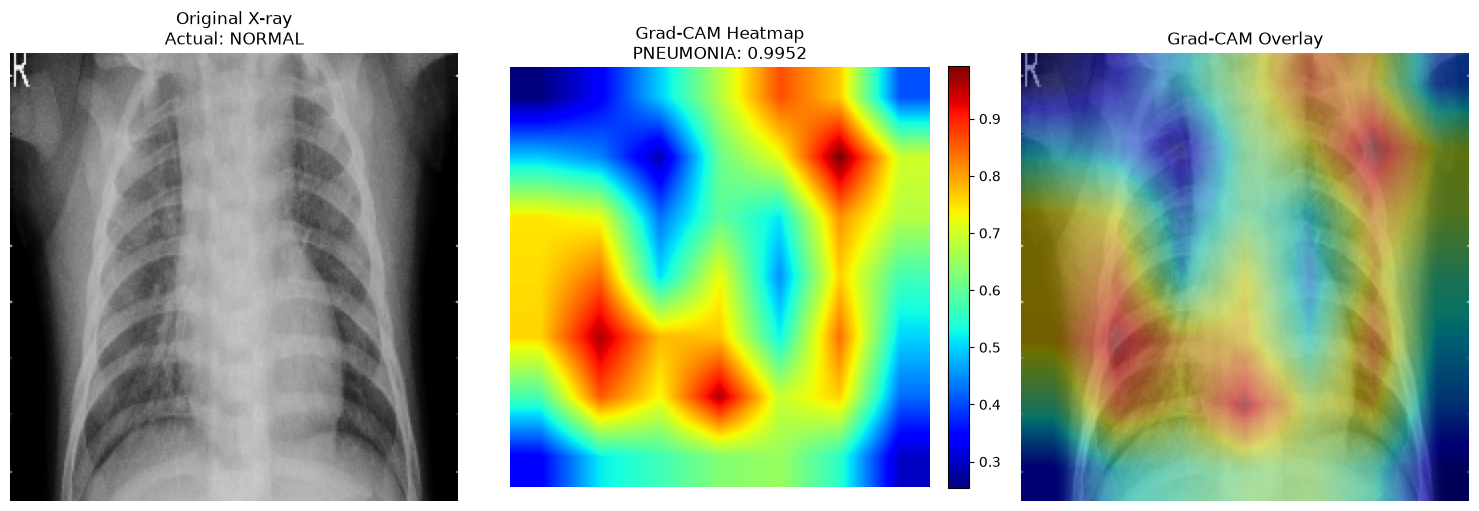

In [68]:
# Visualize the original X-ray, Grad-CAM heatmap, and overlay

xray_image = img_array[0].numpy().astype("uint8")

plt.figure(figsize=(15, 5))

# Original X-ray
plt.subplot(1, 3, 1)
plt.imshow(xray_image)
plt.title("Original X-ray\nActual: NORMAL")
plt.axis("off")

# Grad-CAM heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title(
    f"Grad-CAM Heatmap\n"
    f"PNEUMONIA: {predicted_probability:.4f}"
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(xray_image)
plt.imshow(heatmap_resized, cmap="jet", alpha=0.45)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## Interpretation of the Grad-CAM Visualization

The Grad-CAM visualization was generated for the NORMAL image `NORMAL2-IM-0256-0001.jpeg`, which was incorrectly classified as PNEUMONIA with a predicted probability of **0.9952**.

The heatmap shows that the model's strongest activations are distributed across multiple regions of the chest rather than being concentrated on a single localized area. Prominent activation can be observed in central and peripheral thoracic regions.

This suggests that the MobileNetV2 model is using broad spatial and visual patterns from the chest X-ray when producing its PNEUMONIA prediction. However, the visualization does not provide sufficient evidence to determine whether these highlighted areas correspond to clinically meaningful abnormalities.

The result is particularly important because the image is a **false-positive prediction**. The model is therefore associating certain visual characteristics of this NORMAL image with the PNEUMONIA class.

Possible contributing factors may include differences in image texture, intensity, positioning, anatomical framing, or other dataset-specific visual characteristics. Grad-CAM alone cannot determine which of these factors caused the misclassification.

Further analysis will therefore be performed on additional false-positive and correctly classified images to determine whether similar activation patterns occur consistently.

## Grad-CAM Analysis of a Correctly Classified NORMAL Image

To determine whether the false-positive Grad-CAM pattern is unusual, a correctly classified NORMAL chest X-ray will be analyzed using the same Grad-CAM procedure.

Comparing the two cases allows us to examine whether the model focuses on similar or different regions when it correctly identifies a NORMAL image versus incorrectly predicting PNEUMONIA.

The comparison is exploratory and is intended to identify differences in the model's learned visual attention patterns.

In [69]:
class GradCAMModel(tf.keras.Model):

    def __init__(self, full_model, backbone, target_layer_name="Conv_1"):
        super().__init__()

        self.full_model = full_model
        self.backbone = backbone
        self.target_layer = backbone.get_layer(target_layer_name)

        self.captured_activation = None

    def call(self, inputs, training=False):

        # Run the complete trained model normally.
        predictions = self.full_model(inputs, training=training)

        return predictions


gradcam_model = GradCAMModel(
    model,
    base_model,
    target_layer_name="Conv_1"
)

print("Grad-CAM model created.")
print("Target layer:", gradcam_model.target_layer.name)

Grad-CAM model created.
Target layer: Conv_1


## Selecting a Correctly Classified NORMAL Case

A correctly classified NORMAL chest X-ray is selected from the untouched test set to provide a comparison with the previously analyzed false-positive case.

This image was correctly predicted as NORMAL using the classification threshold selected from the validation set. Its Grad-CAM visualization will be generated using exactly the same procedure as the false-positive case.

The comparison will help determine whether the model's spatial activation pattern changes when its prediction is correct.

In [70]:
# Select a correctly classified NORMAL image

normal_correct_indices = np.where(
    (y_true == 0) & (y_test_pred == 0)
)[0]

correct_index = normal_correct_indices[0]

correct_image_path = normal_files[correct_index]
correct_probability = y_prob[correct_index]

print("Image:", correct_image_path.name)
print("Actual class: NORMAL")
print("Predicted class: NORMAL")
print(f"PNEUMONIA probability: {correct_probability:.4f}")

Image: IM-0001-0001.jpeg
Actual class: NORMAL
Predicted class: NORMAL
PNEUMONIA probability: 0.3980


## Generating Grad-CAM for the Correctly Classified NORMAL Image

The correctly classified NORMAL image `IM-0001-0001.jpeg` has a PNEUMONIA probability of **0.3980**, which is below the locked classification threshold of **0.55**.

Grad-CAM will be generated using the same procedure applied to the previous false-positive case. This consistency is important because it allows the two activation maps to be compared without changing the explainability method.

The resulting visualization will show which regions contributed most strongly to the model's PNEUMONIA score for a case that was ultimately classified as NORMAL.

In [71]:
# Load the correctly classified NORMAL image

correct_image_bytes = tf.io.read_file(str(correct_image_path))

correct_img = tf.image.decode_jpeg(
    correct_image_bytes,
    channels=3
)

correct_img = tf.image.resize(
    correct_img,
    [224, 224]
)

correct_img_array = tf.expand_dims(correct_img, axis=0)

print("Image shape:", correct_img_array.shape)
print("Pixel range:",
      float(tf.reduce_min(correct_img_array)),
      "to",
      float(tf.reduce_max(correct_img_array)))

Image shape: (1, 224, 224, 3)
Pixel range: 6.165231227874756 to 255.0


## Computing Grad-CAM for the Correctly Classified NORMAL Image

The correctly classified NORMAL X-ray will now be passed through the original trained model while the `Conv_1` activation is captured.

The gradient of the model's PNEUMONIA score with respect to this activation will then be calculated.

Using the same procedure as the false-positive case ensures that the two Grad-CAM results are directly comparable.

In [72]:
# Calculate Grad-CAM gradients for the correctly classified NORMAL image

captured_correct = {}

original_conv_call = conv_layer.call


def hooked_conv_call_correct(*args, **kwargs):
    output = original_conv_call(*args, **kwargs)
    captured_correct["activation"] = output
    return output


# Temporarily attach the hook
conv_layer.call = hooked_conv_call_correct

try:
    with tf.GradientTape() as tape:

        # Original trained model forward pass
        correct_prediction = model(
            correct_img_array,
            training=False
        )

        # Conv_1 activation from the same forward pass
        correct_conv_activation = captured_correct["activation"]

        # PNEUMONIA score
        correct_pneumonia_score = correct_prediction[:, 0]

    # Gradients of PNEUMONIA score with respect to Conv_1
    correct_grads = tape.gradient(
        correct_pneumonia_score,
        correct_conv_activation
    )

finally:
    # Restore original layer behavior
    conv_layer.call = original_conv_call


print(
    "Conv_1 activation shape:",
    correct_conv_activation.shape
)

print(
    "Gradient shape:",
    correct_grads.shape
)

print(
    f"PNEUMONIA probability: "
    f"{float(correct_prediction[0, 0]):.4f}"
)

print(
    "Gradient successfully computed:",
    correct_grads is not None
)

Conv_1 activation shape: (1, 7, 7, 1280)
Gradient shape: (1, 7, 7, 1280)
PNEUMONIA probability: 0.3975
Gradient successfully computed: True


## Generating the Grad-CAM Heatmap for the Correctly Classified NORMAL Image

The gradients and `Conv_1` feature maps obtained from the correctly classified NORMAL image will now be converted into a Grad-CAM heatmap.

The same weighted feature-map procedure used for the false-positive case is applied here. This produces a spatial representation of the regions contributing to the model's PNEUMONIA score.

Because this image was correctly classified as NORMAL, the resulting heatmap provides a useful comparison with the high-confidence false-positive example.

In [73]:
# Generate Grad-CAM heatmap for the correctly classified NORMAL image

correct_pooled_grads = tf.reduce_mean(
    correct_grads,
    axis=(1, 2)
)

correct_activation = correct_conv_activation[0]
correct_channel_weights = correct_pooled_grads[0]

correct_weighted_activations = (
    correct_activation * correct_channel_weights
)

correct_heatmap_tensor = tf.reduce_sum(
    correct_weighted_activations,
    axis=-1
)

# Retain positive contributions
correct_heatmap_tensor = tf.maximum(
    correct_heatmap_tensor,
    0
)

# Normalize to 0–1
correct_heatmap_tensor = correct_heatmap_tensor / (
    tf.reduce_max(correct_heatmap_tensor)
    + tf.keras.backend.epsilon()
)

correct_heatmap = correct_heatmap_tensor.numpy()

print("Grad-CAM heatmap shape:", correct_heatmap.shape)
print(f"Heatmap minimum: {correct_heatmap.min():.4f}")
print(f"Heatmap maximum: {correct_heatmap.max():.4f}")
print(f"Heatmap mean: {correct_heatmap.mean():.4f}")

Grad-CAM heatmap shape: (7, 7)
Heatmap minimum: 0.0000
Heatmap maximum: 1.0000
Heatmap mean: 0.2722


## Visualizing the Correctly Classified NORMAL Grad-CAM

The Grad-CAM heatmap for `IM-0001-0001.jpeg` will be resized from **7 × 7** to **224 × 224** and overlaid on the original X-ray.

The same visualization format used for the false-positive case is retained so that the two examples can be compared consistently.

The objective is to examine whether the model's PNEUMONIA-related activation is more localized or differently distributed when the model correctly identifies a NORMAL image.

In [74]:
# Resize the correctly classified Grad-CAM heatmap

correct_heatmap_resized = tf.image.resize(
    correct_heatmap[..., np.newaxis],
    [224, 224]
).numpy().squeeze()

print("Resized heatmap shape:", correct_heatmap_resized.shape)
print(
    f"Resized heatmap range: "
    f"{correct_heatmap_resized.min():.4f} "
    f"to {correct_heatmap_resized.max():.4f}"
)

Resized heatmap shape: (224, 224)
Resized heatmap range: 0.0000 to 0.9902


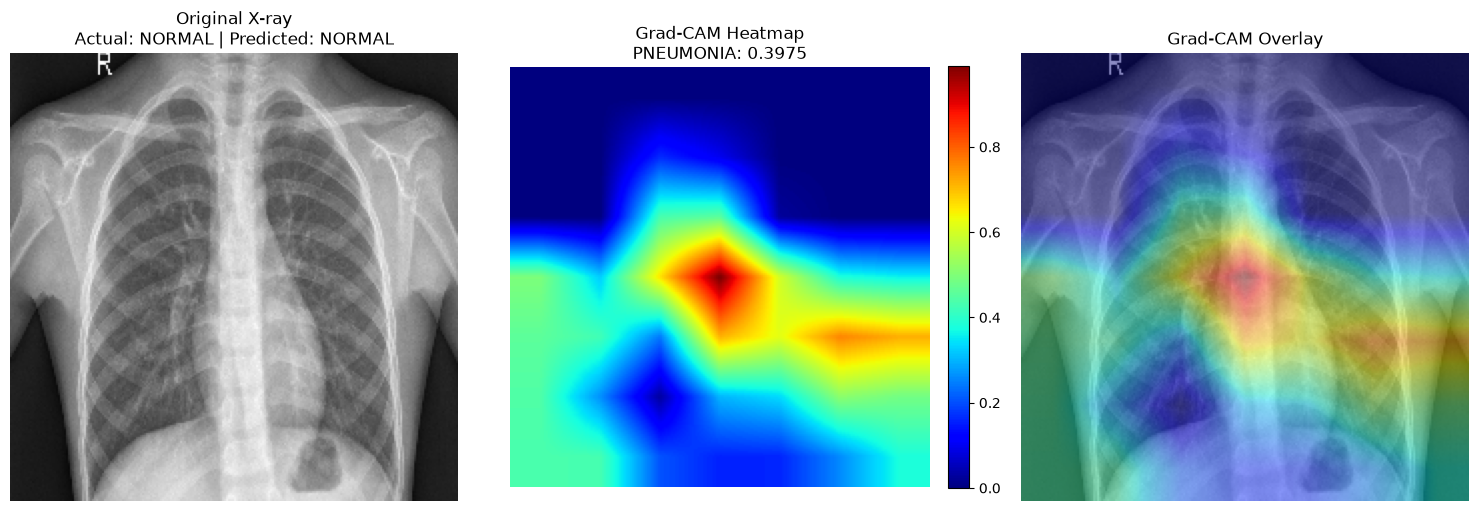

In [75]:
# Visualize the correctly classified NORMAL case

correct_xray_image = correct_img_array[0].numpy().astype("uint8")

plt.figure(figsize=(15, 5))

# Original X-ray
plt.subplot(1, 3, 1)
plt.imshow(correct_xray_image)
plt.title(
    "Original X-ray\n"
    "Actual: NORMAL | Predicted: NORMAL"
)
plt.axis("off")

# Grad-CAM heatmap
plt.subplot(1, 3, 2)
plt.imshow(correct_heatmap_resized, cmap="jet")
plt.title(
    f"Grad-CAM Heatmap\n"
    f"PNEUMONIA: {float(correct_prediction[0, 0]):.4f}"
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(correct_xray_image)
plt.imshow(
    correct_heatmap_resized,
    cmap="jet",
    alpha=0.45
)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## Grad-CAM Comparison: False Positive vs Correct NORMAL

The two Grad-CAM examples show different activation patterns.

The high-confidence false-positive case, `NORMAL2-IM-0256-0001.jpeg`, produced a PNEUMONIA probability of **0.9952** and showed relatively widespread high activation across several regions of the chest. Its mean normalized Grad-CAM value was **0.6298**.

The correctly classified NORMAL case, `IM-0001-0001.jpeg`, produced a PNEUMONIA probability of approximately **0.3975** and showed a more concentrated activation pattern. Its mean normalized Grad-CAM value was **0.2722**.

The visual comparison suggests that the model's activation pattern differs between these two cases. The false-positive case shows stronger and more distributed activation, whereas the correctly classified NORMAL case shows more localized activation.

However, these two images alone are not sufficient to establish a general relationship between Grad-CAM activation patterns and classification accuracy. The difference may reflect image-specific characteristics, anatomical variation, acquisition conditions, or other visual features present in the dataset.

Therefore, the Grad-CAM comparison is treated as an exploratory qualitative analysis. Additional cases are required before drawing broader conclusions about the model's decision-making behavior.

## Grad-CAM Analysis of a Correctly Classified PNEUMONIA Image

To complete the qualitative Grad-CAM analysis, a correctly classified PNEUMONIA chest X-ray will be examined.

This case represents a **true-positive prediction**, where the ground-truth label is PNEUMONIA and the model also predicts PNEUMONIA.

The Grad-CAM visualization will be generated using the same procedure applied to the false-positive NORMAL and correctly classified NORMAL cases.

Comparing these three cases will provide a qualitative view of how the model's activation patterns differ across correct and incorrect predictions.

In [76]:
# Select a correctly classified PNEUMONIA image

pneumonia_correct_indices = np.where(
    (y_true == 1) & (y_test_pred == 1)
)[0]

# Select the first correctly classified PNEUMONIA case
pneumonia_index = pneumonia_correct_indices[0]

pneumonia_image_path = test_ds.file_paths[pneumonia_index]

pneumonia_probability = y_prob[pneumonia_index]

print("Image:", pneumonia_image_path.split("/")[-1])
print("Actual class: PNEUMONIA")
print("Predicted class: PNEUMONIA")
print(f"PNEUMONIA probability: {pneumonia_probability:.4f}")

Image: person100_bacteria_475.jpeg
Actual class: PNEUMONIA
Predicted class: PNEUMONIA
PNEUMONIA probability: 0.6329


## Preparing the Correctly Classified PNEUMONIA Image

The selected image, `person100_bacteria_475.jpeg`, is a correctly classified PNEUMONIA case with a predicted PNEUMONIA probability of **0.6329**.

The image will be resized to **224 × 224 pixels** and converted to a three-channel representation, matching the input format used by the trained MobileNetV2 model.

The same preprocessing procedure used for the previous Grad-CAM cases will be applied so that the resulting explanations remain comparable.

In [77]:
# Load and prepare the correctly classified PNEUMONIA image

pneumonia_image_bytes = tf.io.read_file(
    str(pneumonia_image_path)
)

pneumonia_img = tf.image.decode_jpeg(
    pneumonia_image_bytes,
    channels=3
)

pneumonia_img = tf.image.resize(
    pneumonia_img,
    [224, 224]
)

pneumonia_img_array = tf.expand_dims(
    pneumonia_img,
    axis=0
)

print("Image shape:", pneumonia_img_array.shape)
print(
    "Pixel range:",
    float(tf.reduce_min(pneumonia_img_array)),
    "to",
    float(tf.reduce_max(pneumonia_img_array))
)

Image shape: (1, 224, 224, 3)
Pixel range: 0.0 to 255.0


## Computing Grad-CAM for the Correctly Classified PNEUMONIA Image

The correctly classified PNEUMONIA X-ray will now be passed through the original trained model while the `Conv_1` activation is captured.

The gradient of the PNEUMONIA prediction with respect to the `Conv_1` feature maps will then be calculated.

The same procedure used for the two NORMAL cases is applied to maintain consistency across the Grad-CAM analysis.

In [78]:
# Calculate Grad-CAM gradients for the correctly classified PNEUMONIA image

captured_pneumonia = {}

original_conv_call = conv_layer.call


def hooked_conv_call_pneumonia(*args, **kwargs):
    output = original_conv_call(*args, **kwargs)
    captured_pneumonia["activation"] = output
    return output


# Temporarily attach the hook
conv_layer.call = hooked_conv_call_pneumonia

try:
    with tf.GradientTape() as tape:

        # Original trained model forward pass
        pneumonia_prediction = model(
            pneumonia_img_array,
            training=False
        )

        # Conv_1 activation from the same forward pass
        pneumonia_conv_activation = captured_pneumonia["activation"]

        # PNEUMONIA score
        pneumonia_score = pneumonia_prediction[:, 0]

    # Calculate gradients
    pneumonia_grads = tape.gradient(
        pneumonia_score,
        pneumonia_conv_activation
    )

finally:
    # Restore original layer behavior
    conv_layer.call = original_conv_call


print(
    "Conv_1 activation shape:",
    pneumonia_conv_activation.shape
)

print(
    "Gradient shape:",
    pneumonia_grads.shape
)

print(
    f"PNEUMONIA probability: "
    f"{float(pneumonia_prediction[0, 0]):.4f}"
)

print(
    "Gradient successfully computed:",
    pneumonia_grads is not None
)

Conv_1 activation shape: (1, 7, 7, 1280)
Gradient shape: (1, 7, 7, 1280)
PNEUMONIA probability: 0.6328
Gradient successfully computed: True


## Generating the Grad-CAM Heatmap for the Correctly Classified PNEUMONIA Image

The `Conv_1` feature maps and their gradients have been obtained from the same forward pass of the trained model.

The gradients are spatially averaged to calculate the importance of each feature channel. These weights are then applied to the corresponding feature maps and combined into a two-dimensional Grad-CAM representation.

Positive contributions are retained using ReLU, and the resulting heatmap is normalized between 0 and 1.

This heatmap will provide the third reference point for comparing model behavior across correctly classified NORMAL, false-positive NORMAL, and correctly classified PNEUMONIA cases.

In [79]:
# Generate Grad-CAM heatmap for the correctly classified PNEUMONIA image

pneumonia_pooled_grads = tf.reduce_mean(
    pneumonia_grads,
    axis=(1, 2)
)

pneumonia_activation = pneumonia_conv_activation[0]
pneumonia_channel_weights = pneumonia_pooled_grads[0]

pneumonia_weighted_activations = (
    pneumonia_activation * pneumonia_channel_weights
)

pneumonia_heatmap_tensor = tf.reduce_sum(
    pneumonia_weighted_activations,
    axis=-1
)

# Keep only positive contributions
pneumonia_heatmap_tensor = tf.maximum(
    pneumonia_heatmap_tensor,
    0
)

# Normalize to 0–1
pneumonia_heatmap_tensor = pneumonia_heatmap_tensor / (
    tf.reduce_max(pneumonia_heatmap_tensor)
    + tf.keras.backend.epsilon()
)

pneumonia_heatmap = pneumonia_heatmap_tensor.numpy()

print("Grad-CAM heatmap shape:", pneumonia_heatmap.shape)
print(f"Heatmap minimum: {pneumonia_heatmap.min():.4f}")
print(f"Heatmap maximum: {pneumonia_heatmap.max():.4f}")
print(f"Heatmap mean: {pneumonia_heatmap.mean():.4f}")

Grad-CAM heatmap shape: (7, 7)
Heatmap minimum: 0.0000
Heatmap maximum: 1.0000
Heatmap mean: 0.2288


## Visualizing the Correctly Classified PNEUMONIA Grad-CAM

The Grad-CAM heatmap for `person100_bacteria_475.jpeg` will be resized from **7 × 7** to **224 × 224** and overlaid on the original chest X-ray.

This completes the three representative Grad-CAM examples used in the qualitative explainability analysis:

- Correctly classified NORMAL
- False-positive NORMAL
- Correctly classified PNEUMONIA

The same visualization procedure is applied to all three cases to maintain consistency.

In [80]:
# Resize the PNEUMONIA Grad-CAM heatmap

pneumonia_heatmap_resized = tf.image.resize(
    pneumonia_heatmap[..., np.newaxis],
    [224, 224]
).numpy().squeeze()

print(
    "Resized heatmap shape:",
    pneumonia_heatmap_resized.shape
)

print(
    f"Resized heatmap range: "
    f"{pneumonia_heatmap_resized.min():.4f} "
    f"to {pneumonia_heatmap_resized.max():.4f}"
)

Resized heatmap shape: (224, 224)
Resized heatmap range: 0.0000 to 0.9957


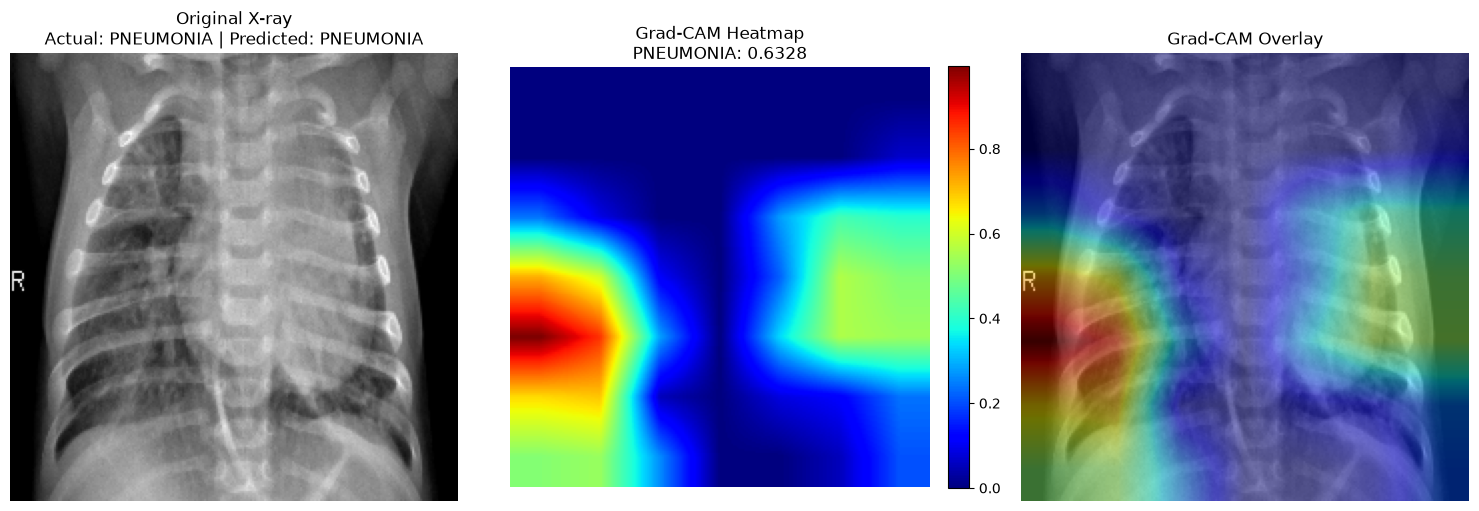

In [81]:
# Visualize the correctly classified PNEUMONIA case

pneumonia_xray_image = (
    pneumonia_img_array[0]
    .numpy()
    .astype("uint8")
)

plt.figure(figsize=(15, 5))

# Original X-ray
plt.subplot(1, 3, 1)
plt.imshow(pneumonia_xray_image)
plt.title(
    "Original X-ray\n"
    "Actual: PNEUMONIA | Predicted: PNEUMONIA"
)
plt.axis("off")

# Grad-CAM heatmap
plt.subplot(1, 3, 2)
plt.imshow(
    pneumonia_heatmap_resized,
    cmap="jet"
)
plt.title(
    f"Grad-CAM Heatmap\n"
    f"PNEUMONIA: {float(pneumonia_prediction[0, 0]):.4f}"
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(pneumonia_xray_image)
plt.imshow(
    pneumonia_heatmap_resized,
    cmap="jet",
    alpha=0.45
)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## Consolidated Grad-CAM Comparison

A consolidated visualization is created to compare the model's activation patterns across three representative test-set cases:

1. **Correctly classified NORMAL**
2. **False-positive NORMAL**
3. **Correctly classified PNEUMONIA**

The same Grad-CAM visualization procedure is used for all three cases. The comparison is qualitative and is intended to illustrate differences in the model's learned visual activation patterns rather than establish a clinical relationship.

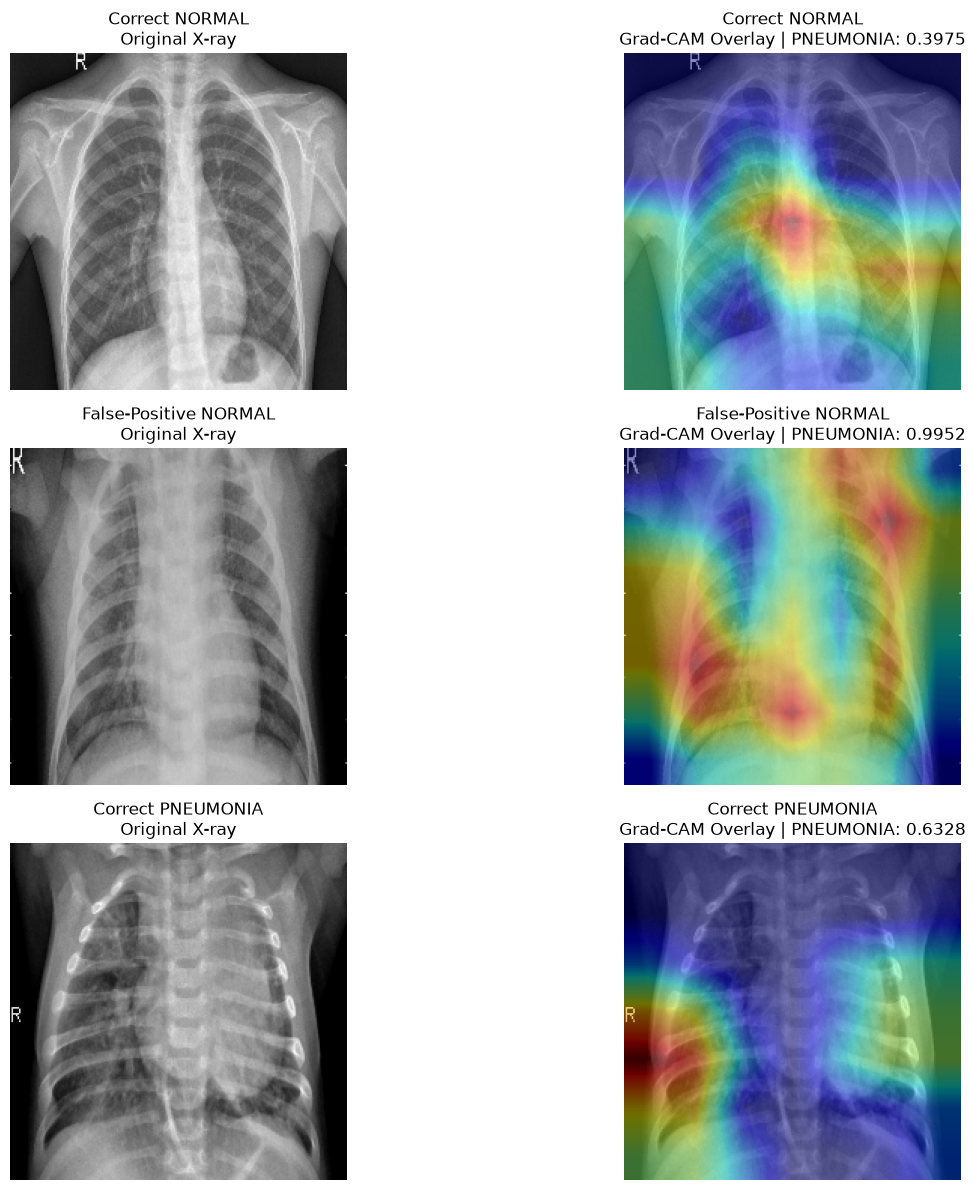

In [82]:
# Consolidated Grad-CAM comparison

cases = [
    (
        correct_xray_image,
        correct_heatmap_resized,
        "Correct NORMAL",
        f"PNEUMONIA: {float(correct_prediction[0, 0]):.4f}"
    ),
    (
        xray_image,
        heatmap_resized,
        "False-Positive NORMAL",
        f"PNEUMONIA: {predicted_probability:.4f}"
    ),
    (
        pneumonia_xray_image,
        pneumonia_heatmap_resized,
        "Correct PNEUMONIA",
        f"PNEUMONIA: {float(pneumonia_prediction[0, 0]):.4f}"
    )
]

plt.figure(figsize=(15, 12))

for i, (image, cam, title, probability) in enumerate(cases):

    plt.subplot(3, 2, 2 * i + 1)
    plt.imshow(image)
    plt.title(f"{title}\nOriginal X-ray")
    plt.axis("off")

    plt.subplot(3, 2, 2 * i + 2)
    plt.imshow(image)
    plt.imshow(cam, cmap="jet", alpha=0.45)
    plt.title(f"{title}\nGrad-CAM Overlay | {probability}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Findings from the Three-Case Grad-CAM Comparison

The consolidated Grad-CAM analysis demonstrates different activation patterns across correctly classified and incorrectly classified cases.

The correctly classified NORMAL image, `IM-0001-0001.jpeg`, produced a PNEUMONIA probability of approximately **0.3975**. Its Grad-CAM activation was relatively structured, with stronger activation concentrated around the central thoracic region.

The false-positive NORMAL image, `NORMAL2-IM-0256-0001.jpeg`, produced a very high PNEUMONIA probability of **0.9952**. Its activation was more widespread across the chest, with several strongly activated regions. This indicates that the model associated multiple visual characteristics of this NORMAL image with the PNEUMONIA class.

The correctly classified PNEUMONIA image, `person100_bacteria_475.jpeg`, produced a PNEUMONIA probability of approximately **0.6328**. Its strongest activation was concentrated more toward the lower and peripheral thoracic regions.

Overall, the three examples demonstrate that the MobileNetV2 model uses spatially distributed visual information when making its predictions. The false-positive example is particularly important because the model produced a highly confident incorrect prediction while activating multiple regions of the chest.

However, these three examples are qualitative and cannot establish a general relationship between Grad-CAM patterns and disease presence. The highlighted regions should not be interpreted as clinically confirmed abnormalities. A larger systematic explainability analysis would be required to determine whether the observed patterns are consistent across the test set.

The Grad-CAM analysis therefore provides evidence that the trained model is interpretable at a visual level, while also highlighting potential weaknesses in its learned feature representations.

# Final Model Performance and Results

The final MobileNetV2 model was evaluated on the untouched test set using a classification threshold of **0.55**.

The threshold was selected exclusively using the validation set by maximizing the F1-score. It was then locked before evaluating the test set, preventing the test data from influencing the final classification decision.

The following metrics are reported:

- Accuracy
- Precision
- Sensitivity (Recall)
- Specificity
- F1-score
- ROC-AUC

These metrics provide a more complete assessment than accuracy alone, particularly because the dataset contains more PNEUMONIA than NORMAL images and because sensitivity and specificity have different implications for medical image classification.

In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Final locked threshold selected using validation data
FINAL_THRESHOLD = 0.55

# Apply the locked threshold to untouched test predictions
final_test_pred = (y_prob >= FINAL_THRESHOLD).astype(int)

# Calculate confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_true,
    final_test_pred
).ravel()

# Calculate final metrics
final_accuracy = accuracy_score(y_true, final_test_pred)
final_precision = precision_score(y_true, final_test_pred)
final_sensitivity = recall_score(y_true, final_test_pred)
final_specificity = tn / (tn + fp)
final_f1 = f1_score(y_true, final_test_pred)
final_roc_auc = roc_auc_score(y_true, y_prob)

print("Final Test-Set Results")
print("-" * 35)
print(f"Threshold:   {FINAL_THRESHOLD:.2f}")
print(f"Accuracy:    {final_accuracy:.4f}")
print(f"Precision:   {final_precision:.4f}")
print(f"Sensitivity: {final_sensitivity:.4f}")
print(f"Specificity: {final_specificity:.4f}")
print(f"F1-score:    {final_f1:.4f}")
print(f"ROC-AUC:     {final_roc_auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_true, final_test_pred))

Final Test-Set Results
-----------------------------------
Threshold:   0.55
Accuracy:    0.7853
Precision:   0.7510
Sensitivity: 0.9821
Specificity: 0.4573
F1-score:    0.8511
ROC-AUC:     0.9425

Confusion Matrix
[[107 127]
 [  7 383]]


## Final Test-Set Performance

The final MobileNetV2 model was evaluated on the untouched test set using the classification threshold of **0.55**, which was selected using the validation set.

The model achieved a **ROC-AUC of 0.9425**, indicating strong ability to distinguish between NORMAL and PNEUMONIA cases based on its predicted probabilities.

At the selected threshold, the model achieved **98.21% sensitivity**, meaning that it correctly identified most of the PNEUMONIA cases. The model achieved **75.10% precision**, while specificity was comparatively lower at **45.73%**.

The difference between sensitivity and specificity indicates that the model has a strong tendency toward detecting PNEUMONIA, but it also produces a substantial number of false-positive predictions among NORMAL images.

The final test-set accuracy was **78.53%**, while the F1-score for the PNEUMONIA class was **85.11%**.

These results demonstrate that the baseline model is particularly strong at minimizing false-negative PNEUMONIA predictions, but further improvement is required to reduce false-positive predictions and increase specificity.

In [85]:
# Create a summary table of the final test-set metrics

final_results = {
    "Metric": [
        "Classification Threshold",
        "Accuracy",
        "Precision",
        "Sensitivity (Recall)",
        "Specificity",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        FINAL_THRESHOLD,
        final_accuracy,
        final_precision,
        final_sensitivity,
        final_specificity,
        final_f1,
        final_roc_auc
    ]
}

for metric, value in zip(
    final_results["Metric"],
    final_results["Value"]
):
    print(f"{metric:<25} {value:.4f}")

Classification Threshold  0.5500
Accuracy                  0.7853
Precision                 0.7510
Sensitivity (Recall)      0.9821
Specificity               0.4573
F1-score                  0.8511
ROC-AUC                   0.9425


## Confusion Matrix Interpretation

The final confusion matrix is:

**[[107, 127], [7, 383]]**

This corresponds to:

- **107 True Negatives:** NORMAL images correctly classified as NORMAL.
- **127 False Positives:** NORMAL images incorrectly classified as PNEUMONIA.
- **7 False Negatives:** PNEUMONIA images incorrectly classified as NORMAL.
- **383 True Positives:** PNEUMONIA images correctly classified as PNEUMONIA.

The relatively small number of false negatives compared with false positives explains the model's very high sensitivity but relatively low specificity.

From a medical image-classification perspective, this behavior is important because missing a PNEUMONIA case can be more concerning than incorrectly flagging a NORMAL case. However, excessive false positives can reduce the practical usefulness of an automated screening system by increasing the number of cases requiring further review.

Therefore, the final results indicate that the MobileNetV2 baseline is effective as a sensitive PNEUMONIA screening model, but specificity remains a major area for improvement.

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve evaluates the model's ability to distinguish between NORMAL and PNEUMONIA across a range of classification thresholds.

Unlike accuracy, precision, sensitivity, and specificity at a single threshold, the ROC curve evaluates the model using its continuous predicted probabilities.

The ROC curve plots:

- **True Positive Rate (Sensitivity)** on the y-axis.
- **False Positive Rate (1 − Specificity)** on the x-axis.

The **Area Under the ROC Curve (ROC-AUC)** summarizes the model's overall discriminative ability. The final MobileNetV2 model achieved a ROC-AUC of **0.9425**, indicating strong separation between the two classes.

The ROC curve is therefore useful for evaluating the model independently of the selected classification threshold of 0.55.

In [86]:
# ROC Curve Analysis

from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    y_prob
)

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_true,
    y_prob
)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Number of ROC points: {len(fpr)}")

ROC-AUC: 0.9425
Number of ROC points: 132


## Visualizing the ROC Curve

The ROC curve provides a visual representation of the model's discrimination ability across different classification thresholds.

A model with stronger class-separation capability produces a curve that approaches the upper-left corner of the plot. The diagonal reference line represents random classification, corresponding to an ROC-AUC of 0.50.

The ROC curve for ChestVision AI will be plotted together with the random-classification baseline. The previously selected classification threshold of **0.55** is not required for constructing the ROC curve because ROC analysis uses the complete range of predicted probabilities.

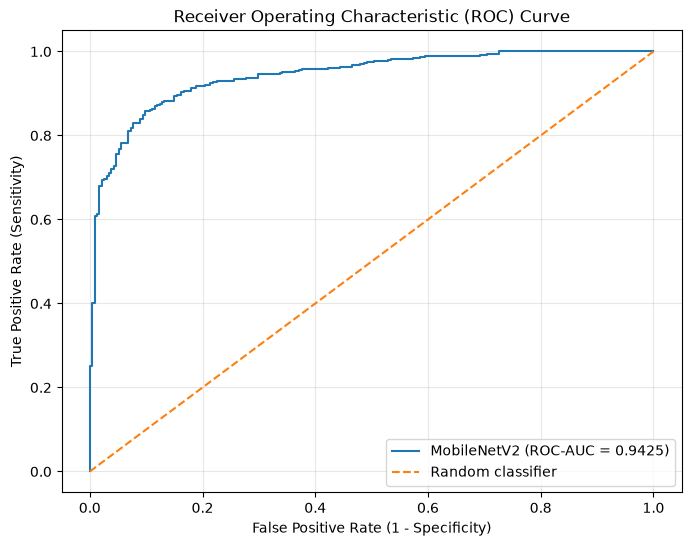

In [87]:
# Plot the ROC curve

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"MobileNetV2 (ROC-AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

## Interpretation of the ROC Curve

The ROC curve demonstrates strong discriminative performance of the MobileNetV2 model across different classification thresholds.

The model achieved a **ROC-AUC of 0.9425**, indicating that the predicted probability scores provide strong separation between NORMAL and PNEUMONIA cases.

The ROC-AUC is substantially higher than the 0.50 random-classification baseline, demonstrating that the model has learned meaningful visual patterns associated with the two classes.

However, ROC-AUC does not indicate that the model performs equally well at every operating point. At the selected threshold of **0.55**, the model achieved very high sensitivity (**98.21%**) but comparatively low specificity (**45.73%**). Therefore, threshold-specific clinical or operational performance must still be considered alongside the overall ROC-AUC.

## Precision–Recall Curve Analysis

The Precision–Recall (PR) curve evaluates the trade-off between **precision** and **recall (sensitivity)** across different classification thresholds.

The curve plots:

- **Precision** on the y-axis.
- **Recall (Sensitivity)** on the x-axis.

PR analysis is particularly informative for ChestVision AI because the final test-set results show very high sensitivity but comparatively lower precision and specificity. Therefore, examining precision and recall across thresholds helps evaluate how the model behaves when the decision threshold changes.

The **Average Precision (AP)** score summarizes the Precision–Recall curve and provides a threshold-independent measure of the model's ability to identify PNEUMONIA cases while maintaining precision.

In [88]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision–Recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_true,
    y_prob
)

# Calculate Average Precision
average_precision = average_precision_score(
    y_true,
    y_prob
)

print(f"Average Precision (AP): {average_precision:.4f}")
print(f"Number of PR points: {len(precision_curve)}")

Average Precision (AP): 0.9660
Number of PR points: 619


## Visualizing the Precision–Recall Curve

The Precision–Recall curve shows how precision changes as recall is varied across different classification thresholds.

A model that maintains high precision while achieving high recall provides a better balance between identifying PNEUMONIA cases and limiting false-positive predictions.

The ChestVision AI model achieved an **Average Precision (AP) of 0.9660**, indicating strong performance across the range of probability thresholds.

The PR curve is especially relevant to this project because the selected threshold of **0.55** produces very high sensitivity but also a substantial number of false-positive NORMAL predictions.

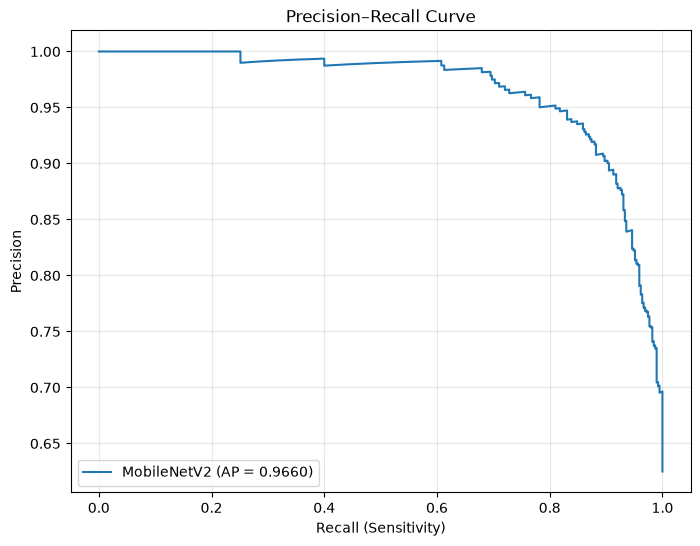

In [89]:
# Plot the Precision–Recall curve

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"MobileNetV2 (AP = {average_precision:.4f})"
)

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.show()

## Interpretation of the Precision–Recall Curve

The Precision–Recall curve demonstrates strong performance of the MobileNetV2 model across a range of classification thresholds.

The model achieved an **Average Precision of 0.9660**, indicating that it generally assigns higher predicted probabilities to PNEUMONIA cases than to NORMAL cases.

The high Average Precision complements the **ROC-AUC of 0.9425** and indicates that the model has strong overall ranking ability.

However, the PR curve also demonstrates an important distinction between probability ranking and performance at a particular operating threshold. Despite the strong threshold-independent performance, the selected threshold of **0.55** produced **98.21% sensitivity** but only **75.10% precision**, resulting in **127 false-positive NORMAL predictions**.

Therefore, the model demonstrates strong underlying discriminative capability, while the choice of operating threshold remains important for controlling the trade-off between sensitivity and false-positive rate.

## Overall Model Performance Discussion

The MobileNetV2 transfer-learning model demonstrates strong overall discriminative performance on the test set.

The model achieved a **ROC-AUC of 0.9425** and an **Average Precision of 0.9660**, indicating that the predicted probability scores provide strong separation between NORMAL and PNEUMONIA cases across a range of decision thresholds.

At the locked classification threshold of **0.55**, the model achieved **78.53% accuracy**, **75.10% precision**, **98.21% sensitivity**, **45.73% specificity**, and an **F1-score of 0.8511**.

The most notable characteristic of the model is its very high sensitivity. Only **7 PNEUMONIA images were incorrectly classified as NORMAL**, while **383 PNEUMONIA images were correctly identified**.

However, this sensitivity comes with a substantial false-positive rate. **127 NORMAL images were classified as PNEUMONIA**, resulting in a specificity of only **45.73%**.

The combination of strong ROC-AUC and Average Precision with lower threshold-specific specificity suggests that the model has learned useful discriminative visual representations, but its probability calibration and operating point require further investigation.

This behavior is also consistent with the Grad-CAM analysis, where the model produced a highly confident false-positive prediction and showed distributed activation across several chest regions.

Overall, the MobileNetV2 model provides a strong baseline for the ChestVision AI project, particularly for sensitivity-oriented screening. Nevertheless, it should not be considered a clinically deployable diagnostic system. Further model development, validation, calibration, and evaluation on independent datasets would be required before any real-world medical application.

## Limitations of the Current Study

Several limitations should be considered when interpreting the results.

The dataset contains two classes, NORMAL and PNEUMONIA, and therefore the current model does not address other thoracic diseases or abnormalities.

The validation and test data originate from the same dataset, so performance on an independent external dataset may differ.

The test-set specificity is relatively low at **45.73%**, indicating a substantial number of false-positive predictions.

The Grad-CAM analysis is based on representative examples and provides qualitative insight rather than statistically validated evidence of clinical localization.

The current model is also a transfer-learning baseline based on MobileNetV2. More advanced architectures, preprocessing strategies, class-balancing techniques, calibration methods, and systematic hyperparameter optimization could potentially improve performance.

Finally, automated chest X-ray classification should be treated as a research prototype rather than a substitute for professional clinical interpretation.

# Conclusion

This study developed **ChestVision AI**, a deep-learning-based chest X-ray classification system for detecting PNEUMONIA using the Chest X-Ray Images (Pneumonia) dataset.

A **MobileNetV2 transfer-learning architecture** was trained to classify chest X-ray images into NORMAL and PNEUMONIA categories. A stratified validation split was created from the original training data, while the original test set was kept untouched for final evaluation.

Using a validation-selected classification threshold of **0.55**, the model achieved **78.53% accuracy, 75.10% precision, 98.21% sensitivity, 45.73% specificity, and an F1-score of 0.8511** on the test set. The model also achieved a **ROC-AUC of 0.9425** and an **Average Precision of 0.9660**, demonstrating strong overall class-discrimination capability.

The model's high sensitivity indicates that it was effective at identifying PNEUMONIA cases, with only **7 false-negative predictions** in the test set. However, the relatively low specificity and **127 false-positive predictions** show that reducing false alarms remains a major challenge.

Grad-CAM analysis was additionally performed to improve interpretability. The results demonstrated that the model uses spatial information from the chest region when making predictions, while also showing that some incorrect predictions can be associated with broadly distributed activation patterns.

Overall, the developed system provides a strong **research baseline for automated PNEUMONIA detection from chest X-rays**. The results demonstrate the potential of transfer learning and explainable deep learning for medical image classification while also highlighting the need for further improvement before practical clinical deployment.

# Future Work

Future development of ChestVision AI will focus on improving specificity while maintaining high sensitivity.

Potential directions include comparing MobileNetV2 with other convolutional and modern deep-learning architectures, applying systematic hyperparameter optimization, investigating improved preprocessing and image normalization techniques, evaluating calibration methods, and performing more extensive explainability analysis.

An important future experiment would be to evaluate the final model on an **independent external chest X-ray dataset**. External validation would provide a stronger assessment of whether the learned representations generalize beyond the dataset used in this study.

Future work can also investigate multi-class thoracic disease detection rather than restricting the task to NORMAL versus PNEUMONIA classification.